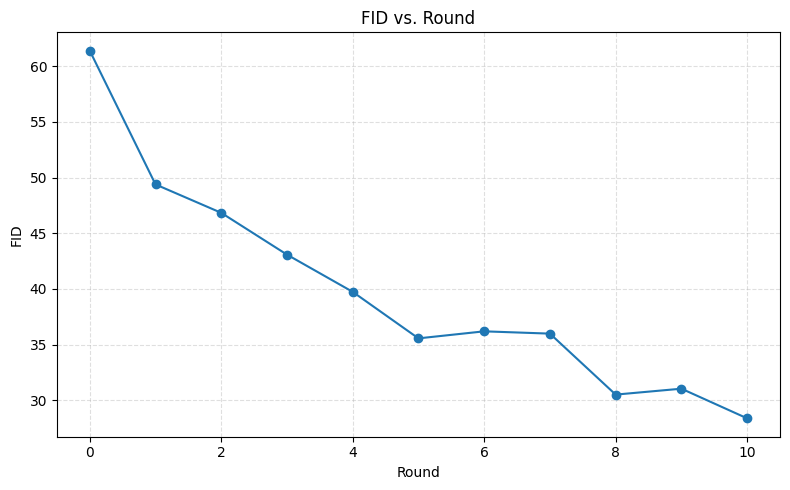

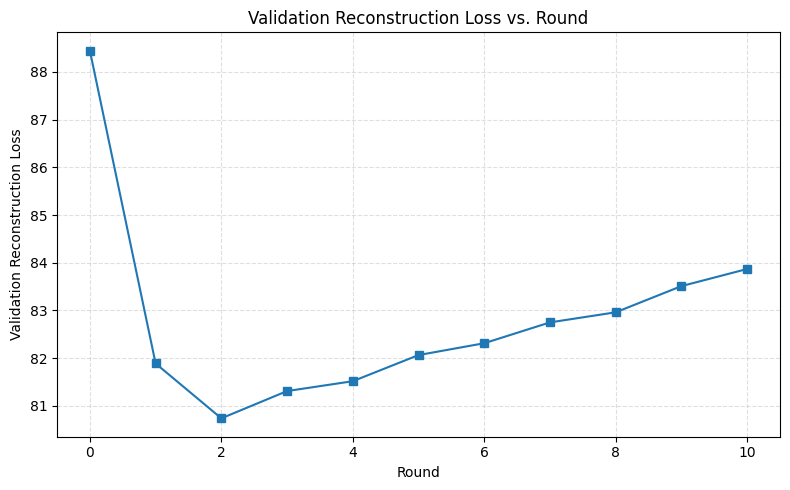

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

# --- config ---
CSV_PATH = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/results_saved_2/results_table_1000_10rounds.csv")

# --- load ---
df = pd.read_csv(CSV_PATH)

# Expect columns: kval_loss, val_recon, val_kl, fid, model_name
required = {"val_loss","val_recon","val_kl","fid","model_name"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"CSV missing columns: {missing}")

# --- add an iteration index from model_name ---
# Treat the seed model (contains 'real_500') as round 0, others as r1..r10
def parse_round(name: str) -> int:
    if "real_500" in name:
        return 0
    m = re.search(r"_r(\d+)$", name)
    if m:
        return int(m.group(1))
    # Fallback: try any trailing digits
    m2 = re.search(r"(\d+)$", name)
    return int(m2.group(1)) if m2 else 0

#df["round"] = df["model_name"].astype(str).apply(parse_round)
df['round']=range(0,11)
df = df.sort_values("round").reset_index(drop=True)
# --- plot FID over rounds ---
plt.figure(figsize=(8, 5))
plt.plot(df["round"], df["fid"], marker="o")
plt.xlabel("Round")
plt.ylabel("FID")
plt.title("FID vs. Round")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# --- plot Validation Reconstruction Loss over rounds ---
plt.figure(figsize=(8, 5))
plt.plot(df["round"], df["val_recon"], marker="s")
plt.xlabel("Round")
plt.ylabel("Validation Reconstruction Loss")
plt.title("Validation Reconstruction Loss vs. Round")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

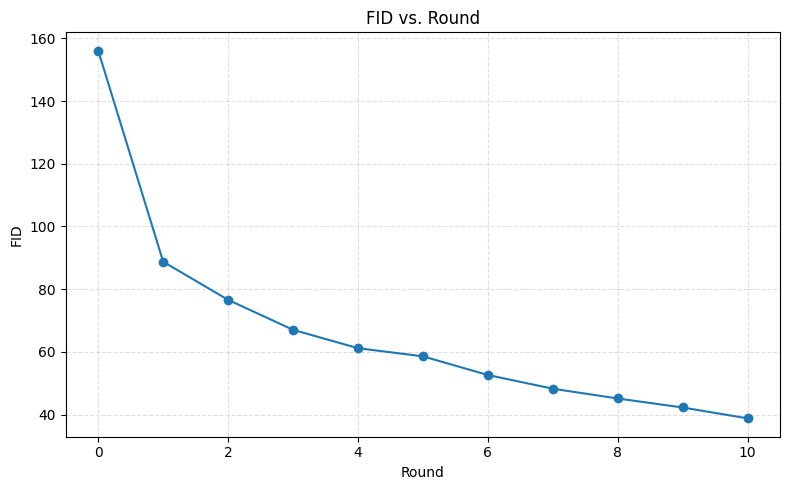

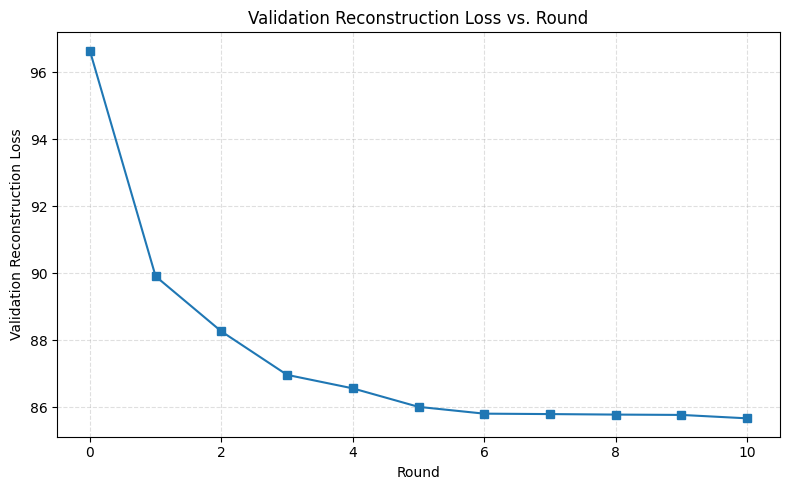

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

# --- config ---
CSV_PATH = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/results_saved/results_table_500_10rounds.csv")

# --- load ---
df = pd.read_csv(CSV_PATH)

# Expect columns: kval_loss, val_recon, val_kl, fid, model_name
required = {"val_loss","val_recon","val_kl","fid","model_name"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"CSV missing columns: {missing}")

# --- add an iteration index from model_name ---
# Treat the seed model (contains 'real_500') as round 0, others as r1..r10
def parse_round(name: str) -> int:
    if "real_500" in name:
        return 0
    m = re.search(r"_r(\d+)$", name)
    if m:
        return int(m.group(1))
    # Fallback: try any trailing digits
    m2 = re.search(r"(\d+)$", name)
    return int(m2.group(1)) if m2 else 0

#df["round"] = df["model_name"].astype(str).apply(parse_round)
df['round']=range(0,11)
df = df.sort_values("round").reset_index(drop=True)
# --- plot FID over rounds ---
plt.figure(figsize=(8, 5))
plt.plot(df["round"], df["fid"], marker="o")
plt.xlabel("Round")
plt.ylabel("FID")
plt.title("FID vs. Round")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# --- plot Validation Reconstruction Loss over rounds ---
plt.figure(figsize=(8, 5))
plt.plot(df["round"], df["val_recon"], marker="s")
plt.xlabel("Round")
plt.ylabel("Validation Reconstruction Loss")
plt.title("Validation Reconstruction Loss vs. Round")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

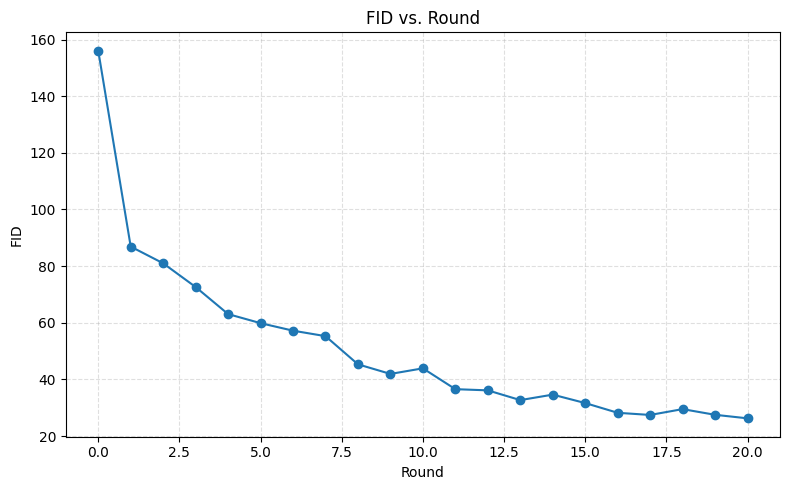

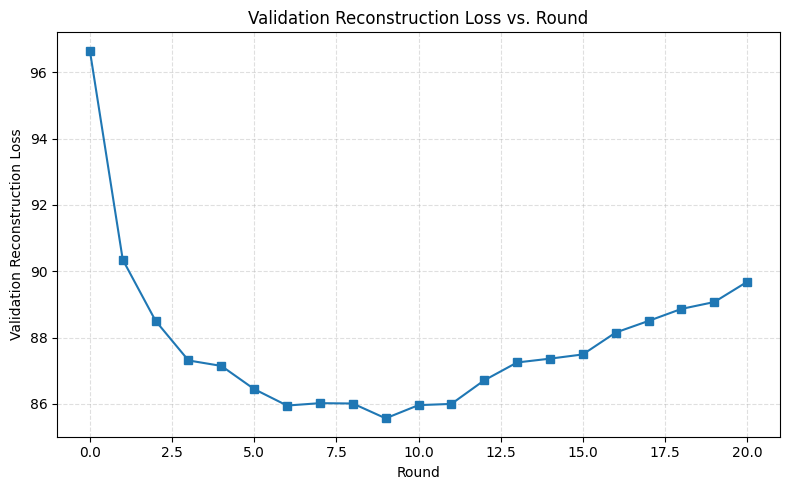

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

# --- config ---
CSV_PATH = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/results_saved_more/results_table_500_20rounds.csv")

# --- load ---
df = pd.read_csv(CSV_PATH)

# Expect columns: kval_loss, val_recon, val_kl, fid, model_name
required = {"val_loss","val_recon","val_kl","fid","model_name"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"CSV missing columns: {missing}")

# --- add an iteration index from model_name ---
# Treat the seed model (contains 'real_500') as round 0, others as r1..r10
def parse_round(name: str) -> int:
    if "real_500" in name:
        return 0
    m = re.search(r"_r(\d+)$", name)
    if m:
        return int(m.group(1))
    # Fallback: try any trailing digits
    m2 = re.search(r"(\d+)$", name)
    return int(m2.group(1)) if m2 else 0

#df["round"] = df["model_name"].astype(str).apply(parse_round)
df['round']=range(0,21)
df = df.sort_values("round").reset_index(drop=True)
# --- plot FID over rounds ---
plt.figure(figsize=(8, 5))
plt.plot(df["round"], df["fid"], marker="o")
plt.xlabel("Round")
plt.ylabel("FID")
plt.title("FID vs. Round")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# --- plot Validation Reconstruction Loss over rounds ---
plt.figure(figsize=(8, 5))
plt.plot(df["round"], df["val_recon"], marker="s")
plt.xlabel("Round")
plt.ylabel("Validation Reconstruction Loss")
plt.title("Validation Reconstruction Loss vs. Round")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

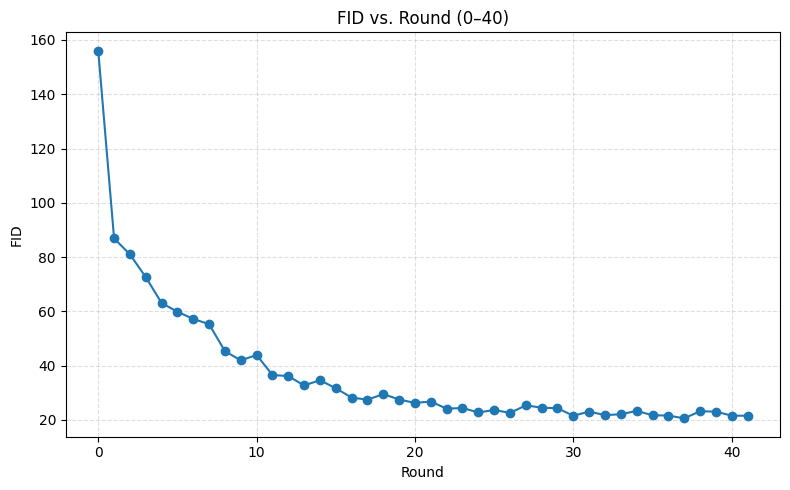

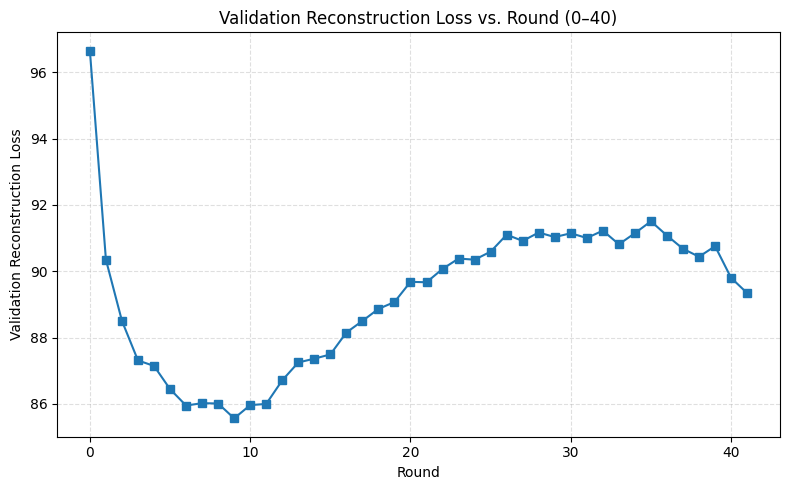

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- config ---
CSV_PATHS = [
    Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/results_saved_more/results_table_500_20rounds.csv"),             # 0–20
    Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/results_saved_more_continue/results_table_500_20rounds.csv"),    # 21–40
]

dfs = []
for i, path in enumerate(CSV_PATHS):
    df = pd.read_csv(path)
    required = {"val_loss","val_recon","val_kl","fid","model_name"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing columns: {missing}")

    # 手动指定 round 范围
    if i == 0:
        df["round"] = range(0, len(df))
    else:
        df["round"] = range(21, 21 + len(df))

    dfs.append(df)

# 合并
df_all = pd.concat(dfs, ignore_index=True)

# --- plot FID ---
plt.figure(figsize=(8, 5))
plt.plot(df_all["round"], df_all["fid"], marker="o")
plt.xlabel("Round")
plt.ylabel("FID")
plt.title("FID vs. Round (0–40)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# --- plot Validation Reconstruction Loss ---
plt.figure(figsize=(8, 5))
plt.plot(df_all["round"], df_all["val_recon"], marker="s")
plt.xlabel("Round")
plt.ylabel("Validation Reconstruction Loss")
plt.title("Validation Reconstruction Loss vs. Round (0–40)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


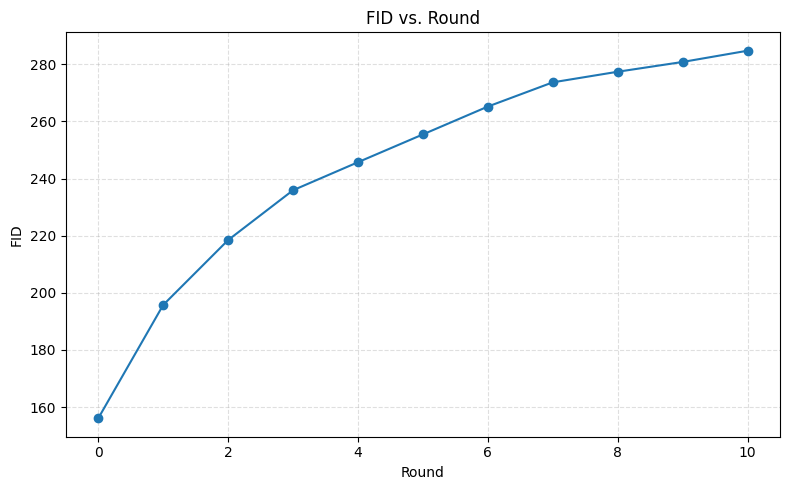

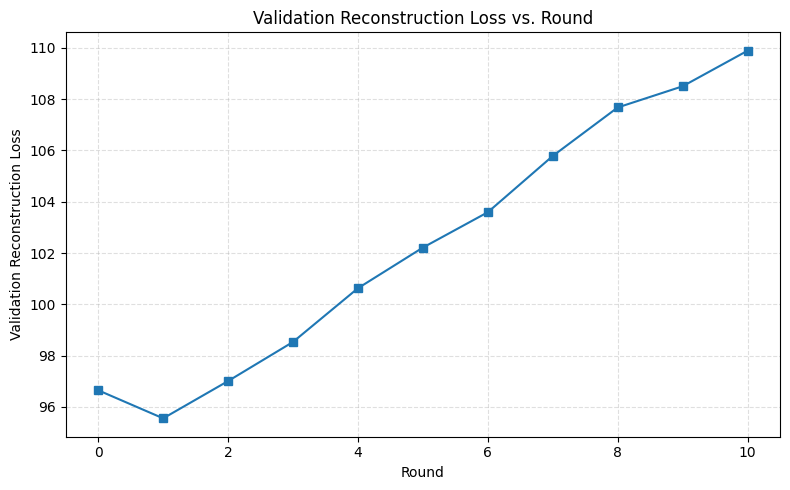

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

# --- config ---
CSV_PATH = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/results_saved_no_filter/results_table_500_10rounds.csv")

# --- load ---
df = pd.read_csv(CSV_PATH)

# Expect columns: kval_loss, val_recon, val_kl, fid, model_name
required = {"val_loss","val_recon","val_kl","fid","model_name"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"CSV missing columns: {missing}")

# --- add an iteration index from model_name ---
# Treat the seed model (contains 'real_500') as round 0, others as r1..r10
def parse_round(name: str) -> int:
    if "real_500" in name:
        return 0
    m = re.search(r"_r(\d+)$", name)
    if m:
        return int(m.group(1))
    # Fallback: try any trailing digits
    m2 = re.search(r"(\d+)$", name)
    return int(m2.group(1)) if m2 else 0

#df["round"] = df["model_name"].astype(str).apply(parse_round)
df['round']=range(0,11)
df = df.sort_values("round").reset_index(drop=True)
# --- plot FID over rounds ---
plt.figure(figsize=(8, 5))
plt.plot(df["round"], df["fid"], marker="o")
plt.xlabel("Round")
plt.ylabel("FID")
plt.title("FID vs. Round")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# --- plot Validation Reconstruction Loss over rounds ---
plt.figure(figsize=(8, 5))
plt.plot(df["round"], df["val_recon"], marker="s")
plt.xlabel("Round")
plt.ylabel("Validation Reconstruction Loss")
plt.title("Validation Reconstruction Loss vs. Round")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

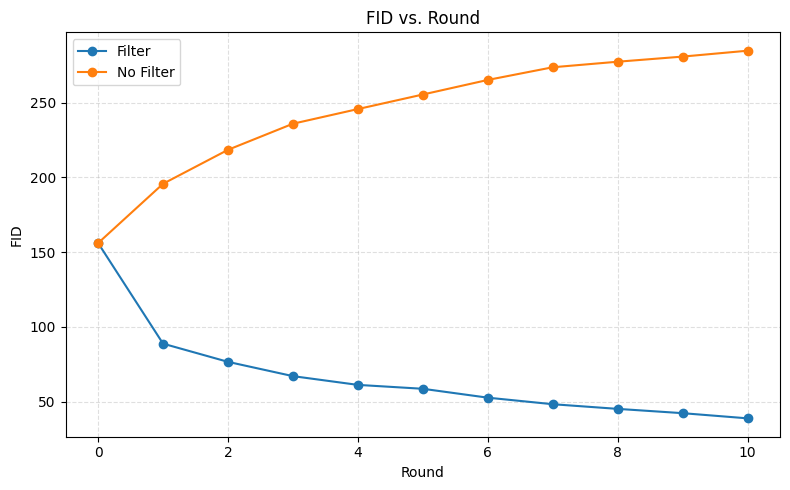

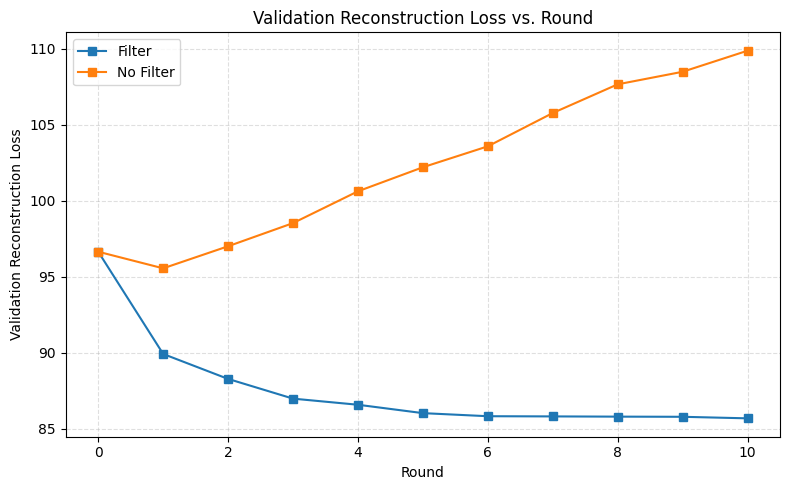

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

def load_results(csv_path, tag):
    df = pd.read_csv(csv_path)
    # 确认必要列
    required = {"val_loss","val_recon","val_kl","fid","model_name"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV {csv_path} missing: {missing}")
    # 添加 round 信息 (假设 0–10)
    df["round"] = range(len(df))
    df["tag"] = tag
    return df

# --- paths ---
CSV_NO_FILTER = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/results_saved_no_filter/results_table_500_10rounds.csv")
CSV_FILTER    = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/results_saved/results_table_500_10rounds.csv")

df_no_filter = load_results(CSV_NO_FILTER, "No Filter")
df_filter    = load_results(CSV_FILTER, "Filter")

# 合并
df_all = pd.concat([df_no_filter, df_filter], ignore_index=True)

# --- plot FID ---
plt.figure(figsize=(8,5))
for tag, group in df_all.groupby("tag"):
    plt.plot(group["round"], group["fid"], marker="o", label=tag)
plt.xlabel("Round")
plt.ylabel("FID")
plt.title("FID vs. Round")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# --- plot Validation Reconstruction Loss ---
plt.figure(figsize=(8,5))
for tag, group in df_all.groupby("tag"):
    plt.plot(group["round"], group["val_recon"], marker="s", label=tag)
plt.xlabel("Round")
plt.ylabel("Validation Reconstruction Loss")
plt.title("Validation Reconstruction Loss vs. Round")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# Plot Summary

⚠️ 以下项目有问题（仍会尽量作图）：
 - [缺目录] /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_512_000/results_saved_more


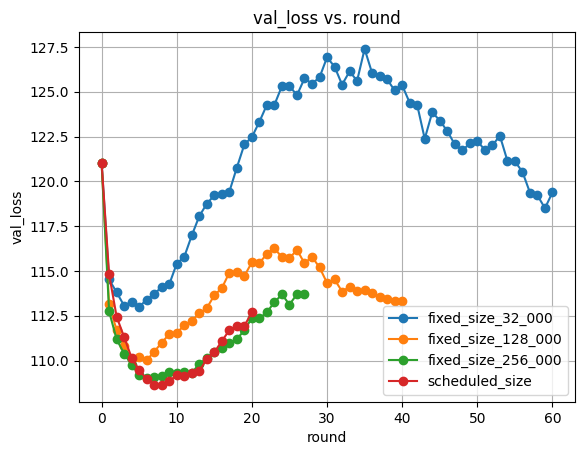

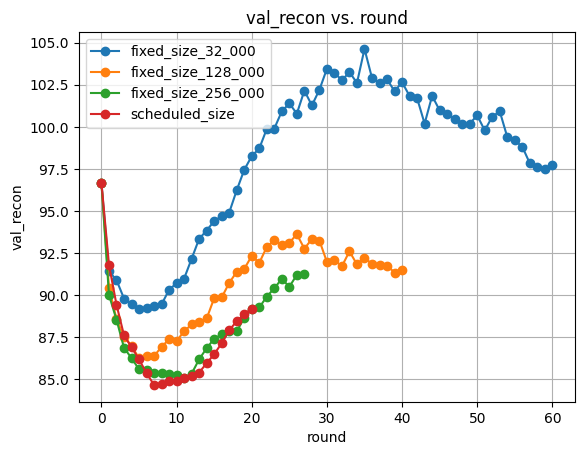

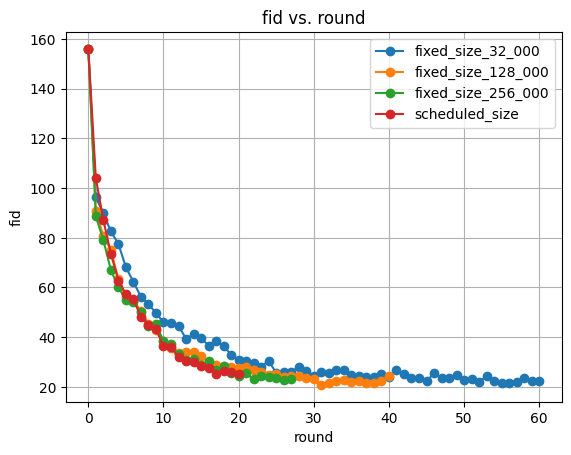

In [3]:

from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- 配置（与你给的一致） ---
folder_path = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/")
subfolders = ["fixed_size_32_000","fixed_size_128_000","fixed_size_256_000","fixed_size_512_000","scheduled_size"]
results_dirname = "results_saved_more"

def parse_round(model_name: str):
    """从 model_name 里解析 round。包含 'real_500' 视为 round 0；其它从 _rN 提取。"""
    if "real_500" in model_name:
        return 0
    m = re.search(r"_r(\d+)", str(model_name))
    return int(m.group(1)) if m else None

# --- 读取所有 CSV ---
frames = []
problems = []

for sub in subfolders:
    csv_dir = folder_path / sub / results_dirname
    if not csv_dir.exists():
        problems.append(f"[缺目录] {csv_dir}")
        continue
    csv_files = sorted(csv_dir.glob("*.csv"))
    if not csv_files:
        problems.append(f"[无CSV] {csv_dir}")
        continue
    
    # 假设每个 schedule 下只有一个 CSV；若有多个，这里默认取“字典序第一个”
    csv_path = csv_files[0]
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        problems.append(f"[读失败] {csv_path}: {e}")
        continue
    
    expected = {"model_name","val_loss","val_recon","val_kl","fid"}
    missing = expected - set(df.columns)
    if missing:
        problems.append(f"[缺列] {csv_path}: {missing}")
        continue
    
    df["schedule"] = sub
    df["round"] = df["model_name"].map(parse_round)
    frames.append(df)

if problems:
    print("⚠️ 以下项目有问题（仍会尽量作图）：")
    for p in problems:
        print(" -", p)

if not frames:
    raise RuntimeError("没有成功读取到任何 CSV。请检查路径/文件。")

combined = pd.concat(frames, ignore_index=True)
# 仅保留能解析出 round 的行
combined = combined[combined["round"].notna()].copy()
combined["round"] = combined["round"].astype(int)
combined.sort_values(by=["schedule","round","model_name"], inplace=True, kind="mergesort")

# 可视化：三张图（每张一个 metric），横轴 round，线条为不同 schedule
metrics = ["val_loss", "val_recon", "fid"]

for metric in metrics:
    plt.figure()
    for sub in subfolders:
        df_sub = combined[(combined["schedule"] == sub)].copy()
        if df_sub.empty:
            continue
        df_sub = df_sub.sort_values("round")
        df_plot = df_sub.groupby("round", as_index=False)[metric].mean()
        plt.plot(df_plot["round"].values, df_plot[metric].values, marker="o", label=sub)
    plt.xlabel("round")
    plt.ylabel(metric)
    plt.title(f"{metric} vs. round")
    plt.legend()
    plt.grid(True)
    plt.show()



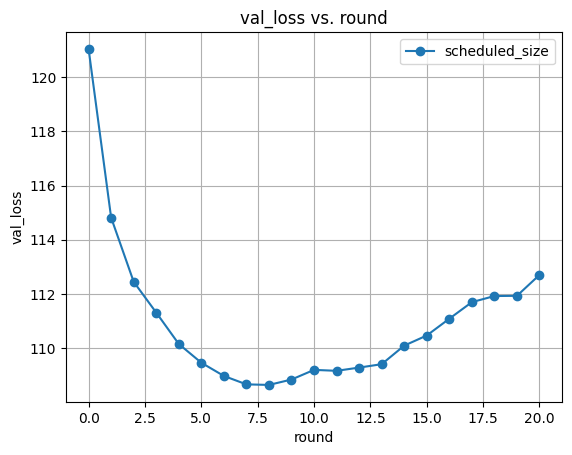

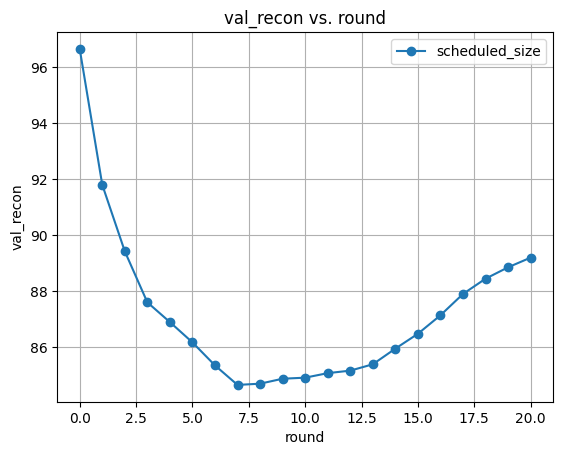

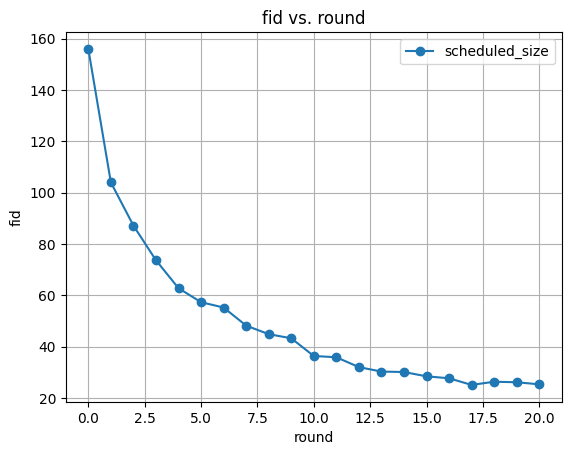

In [4]:

from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- 配置（与你给的一致） ---
folder_path = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/")
subfolders = ["scheduled_size"]
results_dirname = "results_saved_more"

def parse_round(model_name: str):
    """从 model_name 里解析 round。包含 'real_500' 视为 round 0；其它从 _rN 提取。"""
    if "real_500" in model_name:
        return 0
    m = re.search(r"_r(\d+)", str(model_name))
    return int(m.group(1)) if m else None

# --- 读取所有 CSV ---
frames = []
problems = []

for sub in subfolders:
    csv_dir = folder_path / sub / results_dirname
    if not csv_dir.exists():
        problems.append(f"[缺目录] {csv_dir}")
        continue
    csv_files = sorted(csv_dir.glob("*.csv"))
    if not csv_files:
        problems.append(f"[无CSV] {csv_dir}")
        continue
    
    # 假设每个 schedule 下只有一个 CSV；若有多个，这里默认取“字典序第一个”
    csv_path = csv_files[0]
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        problems.append(f"[读失败] {csv_path}: {e}")
        continue
    
    expected = {"model_name","val_loss","val_recon","val_kl","fid"}
    missing = expected - set(df.columns)
    if missing:
        problems.append(f"[缺列] {csv_path}: {missing}")
        continue
    
    df["schedule"] = sub
    df["round"] = df["model_name"].map(parse_round)
    frames.append(df)

if problems:
    print("⚠️ 以下项目有问题（仍会尽量作图）：")
    for p in problems:
        print(" -", p)

if not frames:
    raise RuntimeError("没有成功读取到任何 CSV。请检查路径/文件。")

combined = pd.concat(frames, ignore_index=True)
# 仅保留能解析出 round 的行
combined = combined[combined["round"].notna()].copy()
combined["round"] = combined["round"].astype(int)
combined.sort_values(by=["schedule","round","model_name"], inplace=True, kind="mergesort")

# 可视化：三张图（每张一个 metric），横轴 round，线条为不同 schedule
metrics = ["val_loss", "val_recon", "fid"]

for metric in metrics:
    plt.figure()
    for sub in subfolders:
        df_sub = combined[(combined["schedule"] == sub)].copy()
        if df_sub.empty:
            continue
        df_sub = df_sub.sort_values("round")
        df_plot = df_sub.groupby("round", as_index=False)[metric].mean()
        plt.plot(df_plot["round"].values, df_plot[metric].values, marker="o", label=sub)
    plt.xlabel("round")
    plt.ylabel(metric)
    plt.title(f"{metric} vs. round")
    plt.legend()
    plt.grid(True)
    plt.show()



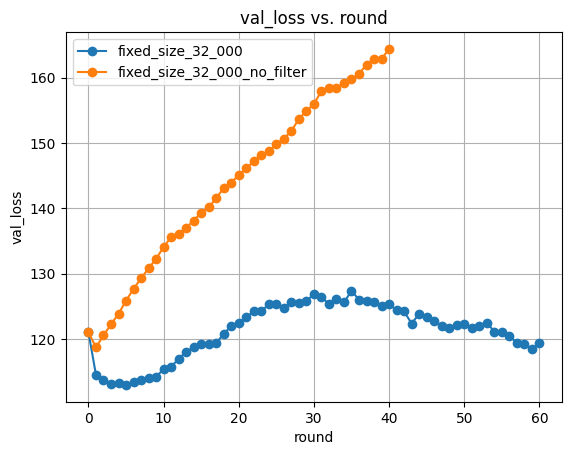

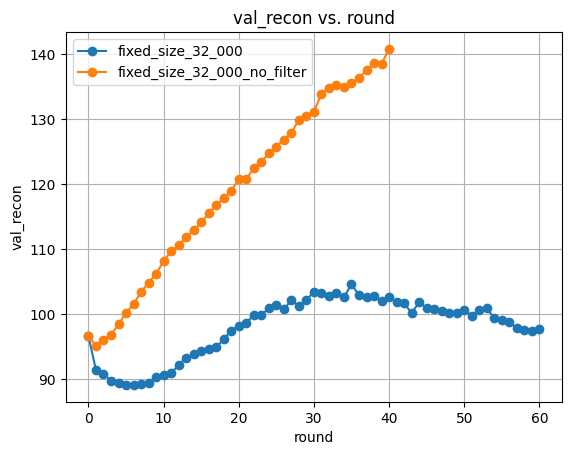

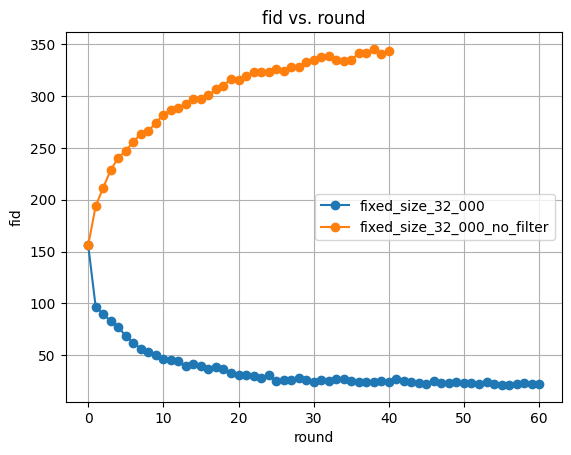

In [6]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

# --- 配置 ---
folder_path = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/")
subfolders = ["fixed_size_32_000","fixed_size_32_000_no_filter"]

# 为不同的 schedule 指定各自的结果目录
results_dir_map = {
    "fixed_size_32_000": "results_saved_more",
    "fixed_size_32_000_no_filter": "results_saved_no_filter_more",
}

def parse_round(model_name: str):
    if "real_500" in model_name:
        return 0
    m = re.search(r"_r(\d+)", str(model_name))
    return int(m.group(1)) if m else None

# --- 读取所有 CSV ---
frames, problems = [], []
for sub in subfolders:
    results_dirname = results_dir_map.get(sub, "results_saved_more")
    csv_dir = folder_path / sub / results_dirname
    if not csv_dir.exists():
        problems.append(f"[缺目录] {csv_dir}")
        continue
    csv_files = sorted(csv_dir.glob("*.csv"))
    if not csv_files:
        problems.append(f"[无CSV] {csv_dir}")
        continue
    csv_path = csv_files[0]
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        problems.append(f"[读失败] {csv_path}: {e}")
        continue

    expected = {"model_name","val_loss","val_recon","val_kl","fid"}
    missing = expected - set(df.columns)
    if missing:
        problems.append(f"[缺列] {csv_path}: {missing}")
        continue

    df["schedule"] = sub
    df["round"] = df["model_name"].map(parse_round)
    frames.append(df)

if problems:
    print("⚠️ 以下项目有问题（仍会尽量作图）：")
    for p in problems: print(" -", p)

if not frames:
    raise RuntimeError("没有成功读取到任何 CSV。请检查路径/文件。")

combined = pd.concat(frames, ignore_index=True)
combined = combined[combined["round"].notna()].copy()
combined["round"] = combined["round"].astype(int)
combined.sort_values(by=["schedule","round","model_name"], inplace=True, kind="mergesort")

# --- 画图：三张图（val_loss / val_recon / fid）---
metrics = ["val_loss", "val_recon", "fid"]
for metric in metrics:
    plt.figure()
    for sub in subfolders:
        df_sub = combined[combined["schedule"] == sub].copy()
        if df_sub.empty: 
            continue
        df_sub = df_sub.sort_values("round")
        df_plot = df_sub.groupby("round", as_index=False)[metric].mean()
        plt.plot(df_plot["round"].values, df_plot[metric].values, marker="o", label=sub)
    plt.xlabel("round")
    plt.ylabel(metric)
    plt.title(f"{metric} vs. round")
    plt.legend()
    plt.grid(True)
    plt.show()


# 32000 120 round

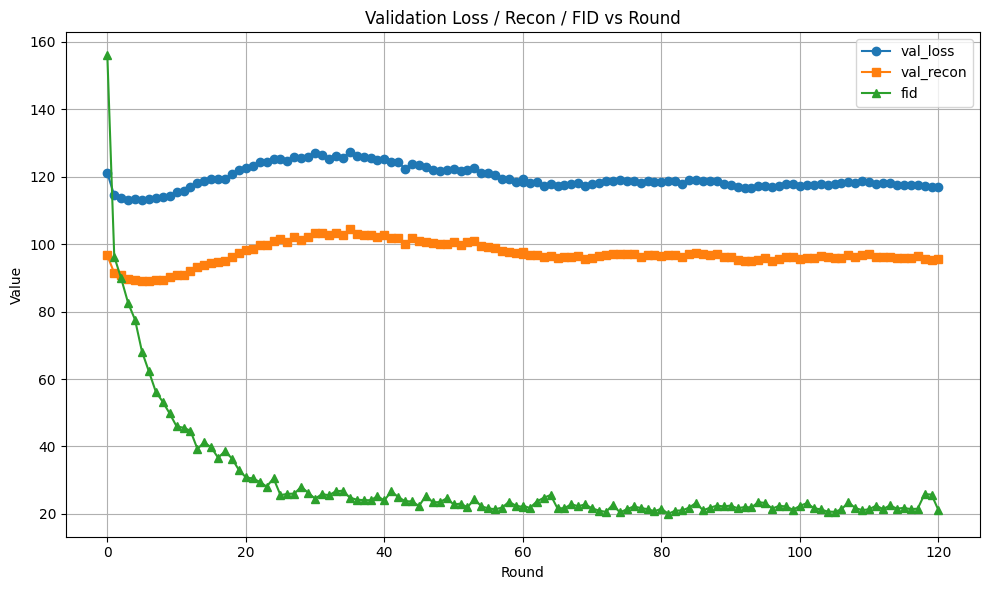

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

# --- paths ---
ROOT = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/")
file1 = ROOT / "fixed_size_32_000/results_saved_more/results_table_500_60rounds.csv"
file2 = ROOT / "fixed_size_32_000_continue/results_saved_more/results_table_500_60rounds.csv"

# --- load ---
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

# --- helper: extract round number ---
def parse_round(name: str) -> int:
    if "real_500" in name:
        return 0
    m = re.search(r"_r(\d+)", name)
    return int(m.group(1)) if m else None

df1["round"] = df1["model_name"].map(parse_round)
df2["round"] = df2["model_name"].map(parse_round)

# concat
df_all = pd.concat([df1, df2], ignore_index=True).sort_values("round")

# --- plot ---
plt.figure(figsize=(10, 6))

plt.plot(df_all["round"], df_all["val_loss"], label="val_loss", marker="o")
plt.plot(df_all["round"], df_all["val_recon"], label="val_recon", marker="s")
plt.plot(df_all["round"], df_all["fid"], label="fid", marker="^")

plt.xlabel("Round")
plt.ylabel("Value")
plt.title("Validation Loss / Recon / FID vs Round")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 256K

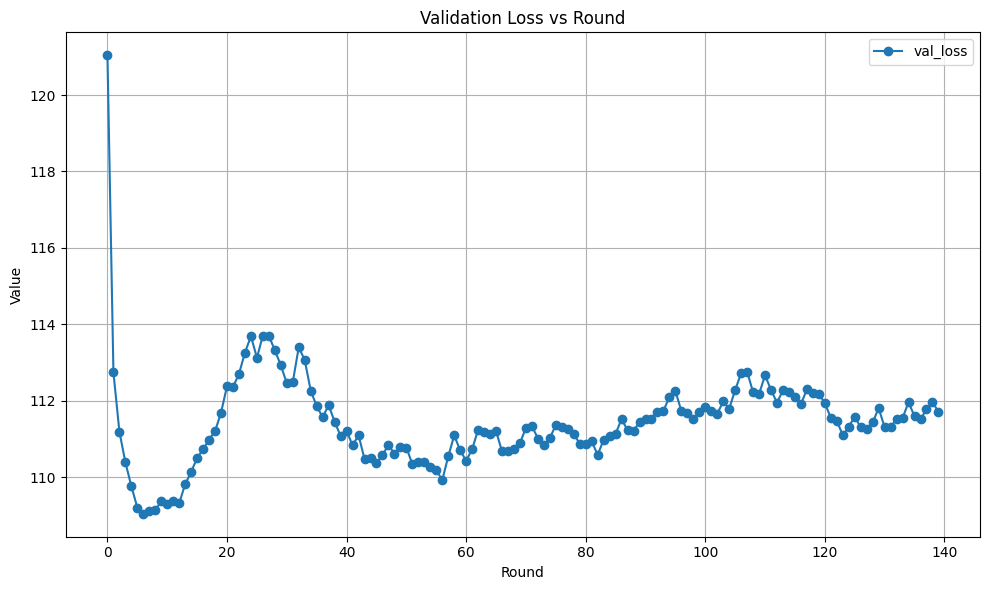

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

# --- paths ---
ROOT = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/")
file1 = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_256_000/results_saved_more/results_table_500_40rounds.csv"
file2 = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/continued_256/results_saved_more/results_table_500_40rounds.csv"
file3 = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/continued_256_2/results_saved_more/results_table_500_40rounds.csv"
file4 = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/continued_256_3/results_saved_more/results_table_500_40rounds.csv"
file5 = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/continued_256_4/results_saved_more/results_table_500_40rounds.csv"
# --- load ---
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)
df4 = pd.read_csv(file4)
df5 = pd.read_csv(file5)

# --- helper: extract round number ---
def parse_round(name: str) -> int:
    if "real_500" in name:
        return 0
    m = re.search(r"_r(\d+)", name)
    return int(m.group(1)) if m else None

df1["round"] = df1["model_name"].map(parse_round)
df2["round"] = df2["model_name"].map(parse_round)
df3["round"] = df3["model_name"].map(parse_round)   
df4["round"] = df4["model_name"].map(parse_round)   
df5["round"] = df5["model_name"].map(parse_round)
# concat
df_all = pd.concat([df1, df2, df3, df4, df5], ignore_index=True).sort_values("round")

# --- plot ---
plt.figure(figsize=(10, 6))

plt.plot(df_all["round"], df_all["val_loss"], label="val_loss", marker="o")
#plt.plot(df_all["round"], df_all["val_recon"], label="val_recon", marker="s")
#plt.plot(df_all["round"], df_all["fid"], label="fid", marker="^")

plt.xlabel("Round")
plt.ylabel("Value")
plt.title("Validation Loss vs Round")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


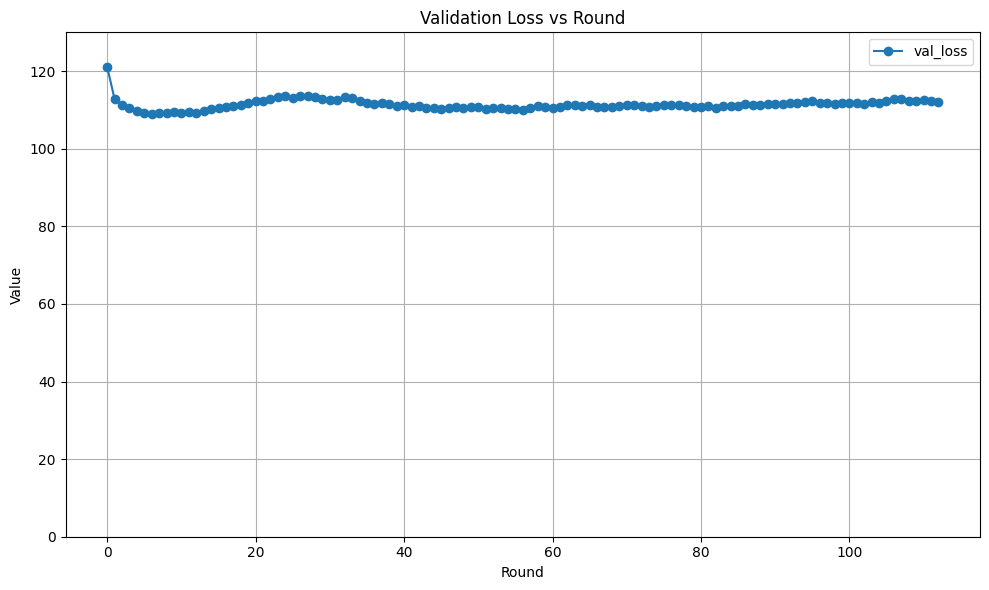

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

# --- paths ---
ROOT = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/")
file1 = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_256_000/results_saved_more/results_table_500_40rounds.csv"
file2 = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/continued_256/results_saved_more/results_table_500_40rounds.csv"
file3 = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/continued_256_2/results_saved_more/results_table_500_40rounds.csv"
file4 = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/continued_256_3/results_saved_more/results_table_500_40rounds.csv"

# --- load ---
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
df3 = pd.read_csv(file3)
df4 = pd.read_csv(file4)    

# --- helper: extract round number ---
def parse_round(name: str) -> int:
    if "real_500" in name:
        return 0
    m = re.search(r"_r(\d+)", name)
    return int(m.group(1)) if m else None

df1["round"] = df1["model_name"].map(parse_round)
df2["round"] = df2["model_name"].map(parse_round)
df3["round"] = df3["model_name"].map(parse_round)
df4["round"] = df4["model_name"].map(parse_round)

# concat
df_all = pd.concat([df1, df2, df3, df4], ignore_index=True).sort_values("round")

# --- plot ---
plt.figure(figsize=(10, 6))

plt.plot(df_all["round"], df_all["val_loss"], label="val_loss", marker="o")
#plt.plot(df_all["round"], df_all["val_recon"], label="val_recon", marker="s")
#plt.plot(df_all["round"], df_all["fid"], label="fid", marker="^")

plt.xlabel("Round")
plt.ylabel("Value")
plt.ylim(bottom=0, top=130)
plt.title("Validation Loss vs Round")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# different sample size compare

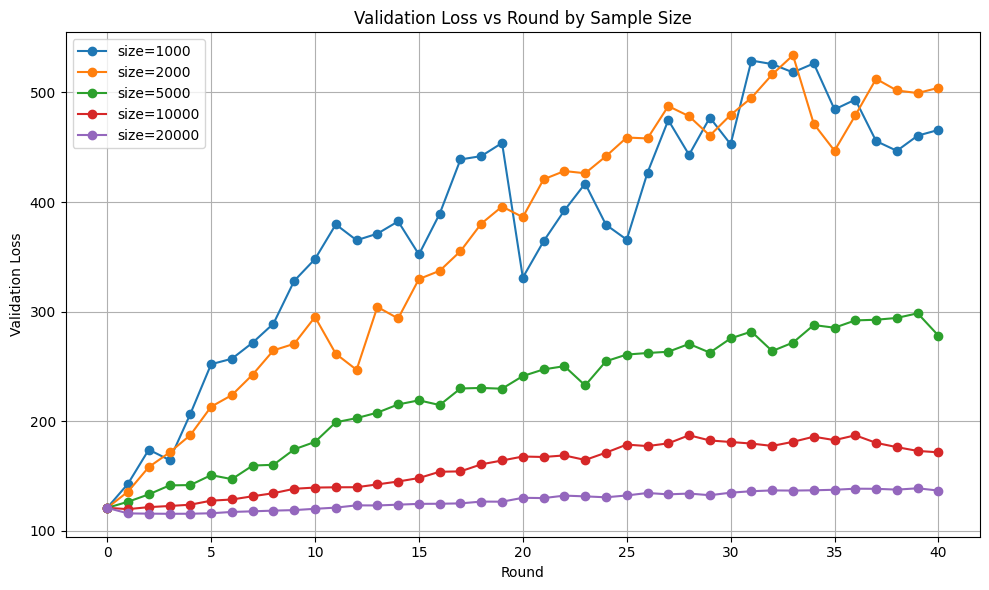

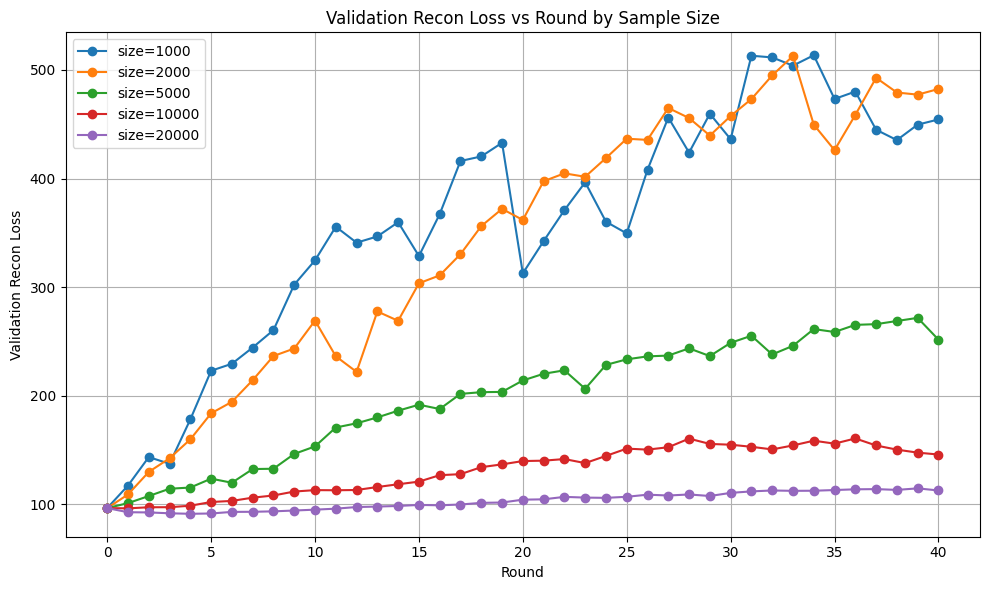

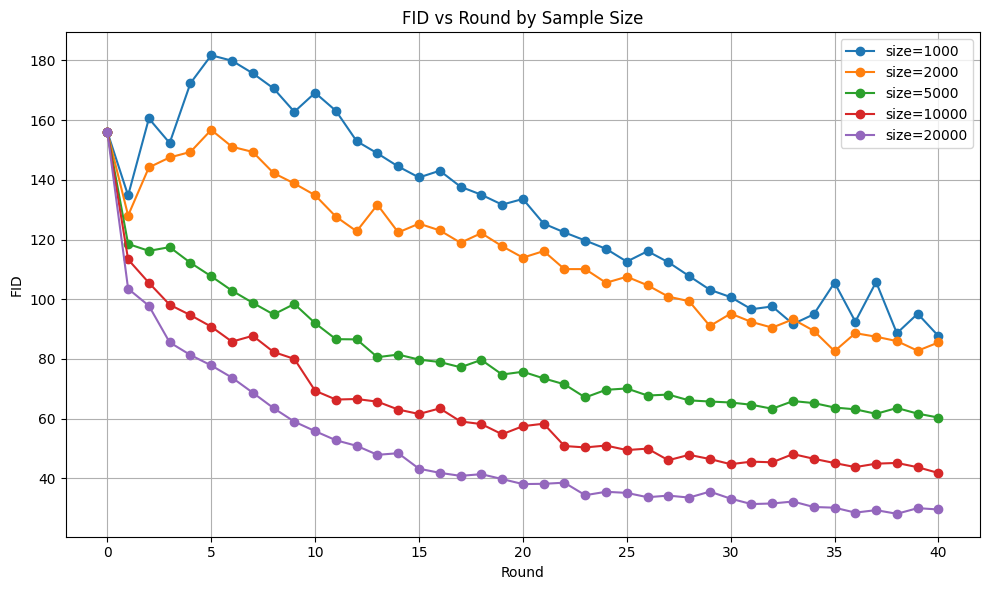

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

# --- config ---
ROOT = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/")
sizes = [1000, 2000, 5000, 10000, 20000]


# --- helper to parse round ---
def parse_round(name: str) -> int:
    if "real_500" in name:
        return 0
    m = re.search(r"_r(\d+)", name)
    return int(m.group(1)) if m else None

# --- load all ---
dfs = []
for s in sizes:
    f = ROOT / f"fixed_size_{s}" / "results_saved_more/results_table_500_40rounds.csv"
    df = pd.read_csv(f)
    df["round"] = df["model_name"].map(parse_round)
    df["size"] = s
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# --- plot function ---
def plot_metric(metric: str, ylabel: str):
    plt.figure(figsize=(10, 6))
    for s in sizes:
        sub = df_all[df_all["size"] == s]
        plt.plot(sub["round"], sub[metric], marker="o", label=f"size={s}")
    plt.xlabel("Round")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs Round by Sample Size")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- make 3 plots ---
plot_metric("val_loss", "Validation Loss")
plot_metric("val_recon", "Validation Recon Loss")
plot_metric("fid", "FID")


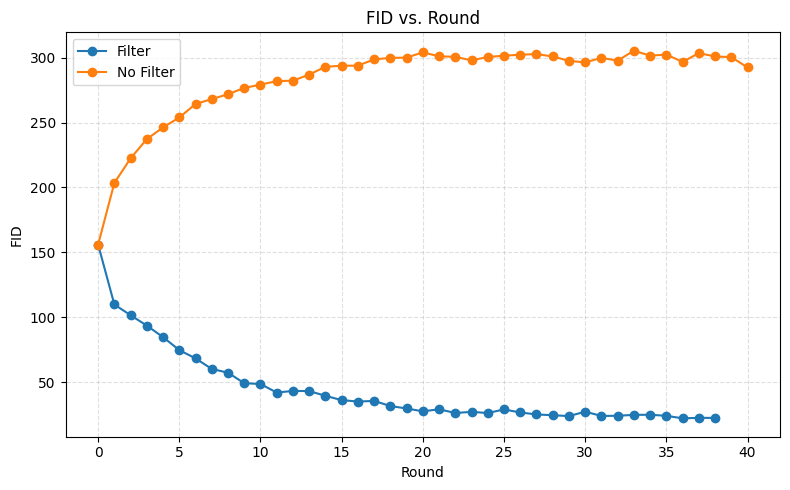

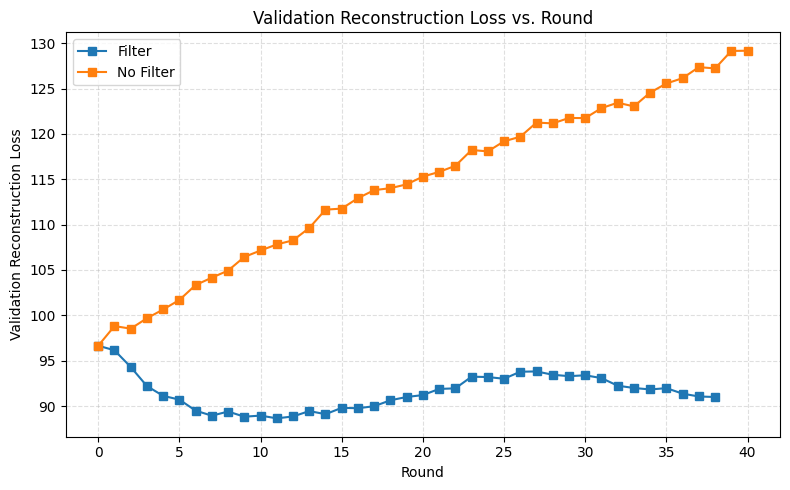

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

def load_results(csv_path, tag):
    df = pd.read_csv(csv_path)
    # 确认必要列
    required = {"val_loss","val_recon","val_kl","fid","model_name"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV {csv_path} missing: {missing}")
    # 添加 round 信息 (假设 0–10)
    df["round"] = range(len(df))
    df["tag"] = tag
    return df

# --- paths ---
CSV_NO_FILTER = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/schedule_size_linear_no_filter/results_saved_no_filter_more/results_table_500_40rounds.csv")
CSV_FILTER    = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/linear_increase/results_saved_more/results_table_500_40rounds.csv")

df_no_filter = load_results(CSV_NO_FILTER, "No Filter")
df_filter    = load_results(CSV_FILTER, "Filter")

# 合并
df_all = pd.concat([df_no_filter, df_filter], ignore_index=True)

# --- plot FID ---
plt.figure(figsize=(8,5))
for tag, group in df_all.groupby("tag"):
    plt.plot(group["round"], group["fid"], marker="o", label=tag)
plt.xlabel("Round")
plt.ylabel("FID")
plt.title("FID vs. Round")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# --- plot Validation Reconstruction Loss ---
plt.figure(figsize=(8,5))
for tag, group in df_all.groupby("tag"):
    plt.plot(group["round"], group["val_recon"], marker="s", label=tag)
plt.xlabel("Round")
plt.ylabel("Validation Reconstruction Loss")
plt.title("Validation Reconstruction Loss vs. Round")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# Train with all data

In [3]:
import sys
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset, Subset
from torchvision.utils import make_grid
import torch.nn.functional as F


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random

vae_path = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
sys.path.append(vae_path)

import models as models
import train_helper as train_helper
import utils as utils
import data_helper as data_helper

# Set up device and seed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_seed = 0
torch.manual_seed(base_seed)
torch.cuda.manual_seed_all(base_seed)
np.random.seed(base_seed)
random.seed(base_seed)

In [5]:

ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"

model_saved_path = os.path.join(ROOT,"model_saved_no_filter")
data_saved_path = os.path.join(ROOT,"data_saved_no_filter")
results_saved_path = os.path.join(ROOT,"results_saved_no_filter")
picture_saved_path = os.path.join(ROOT,"picture_saved_no_filter")

full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())

test_dataset = datasets.MNIST(root="./data", train=False, download=True,transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
full_digit_indices = utils.create_balanced_subset_indices(full_dataset,seed=base_seed)

import torch
import torch.nn.functional as F

@torch.no_grad()
def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    # Balanced label assignment (always length = total_samples)
    labels_full = torch.arange(total_samples) % num_classes

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        n = end - start

        # Sample latent z
        z = torch.randn(n, latent_dim, device=device)

        # Labels
        y = labels_full[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        # Decode logits → sigmoid → [0,1]
        logits_flat = model.decoder.decode(z, y_onehot)     # (n, 784), logits
        imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28).cpu()

        generated_images.append(imgs)
        all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels

from FID import calculate_fid_score

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_model_samples(model, save_path=None, latent_dim=20, num_classes=10, per_class=8, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()

    # latent + labels
    z = torch.randn(num_classes * per_class, latent_dim, device=device)
    y = torch.arange(num_classes, device=device).repeat_interleave(per_class)
    y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

    # decode -> logits, then map to [0,1]
    logits_flat = model.decoder.decode(z, y_onehot)            # (n, 784), logits
    imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28)      # tensor on device, no grad (due to @no_grad)

    # move for plotting
    imgs_np = imgs.detach().cpu().numpy()

    fig, axes = plt.subplots(num_classes, per_class, figsize=(2*per_class, 2*num_classes))
    for c in range(num_classes):
        for j in range(per_class):
            idx = c * per_class + j
            axes[c, j].imshow(imgs_np[idx].squeeze(), cmap='gray')
            axes[c, j].axis('off')
            if j == 0:
                axes[c, j].set_ylabel(f"Class {c}", fontsize=10)

    plt.tight_layout()
    if save_path:
        if not os.path.exists(os.path.dirname(save_path)):
            os.makedirs(os.path.dirname(save_path))
        plt.savefig(save_path, dpi=150)
        print(f"[SAVE] Sample grid saved -> {save_path}")
    return fig, axes


def fid(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    synthetic_gen_size = 6000
    gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
        model=model,
        total_samples=synthetic_gen_size,
        latent_dim=20,
        num_classes=10,
        batch_size=10000,
        device=device
    )
    # Load synthetic data
    #synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
    images = gen_imgs_before_filter # [N, 1, 28, 28]
    labels = y_before_filter  # [N]

    transform = transforms.ToTensor()

    real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    synthetic_ds = TensorDataset(images, labels)
    
    synthetic_ds = TensorDataset(images, labels)
    fid = calculate_fid_score(real_ds, synthetic_ds)
    
    return fid

import shutil

init_size = 500

all_models = []
test_results = {"val_loss":[], "val_recon":[], "val_kl":[], "fid":[],"model_name":[]}
init_loader = DataLoader(full_dataset, batch_size=128, shuffle=True)

this_model = models.CVAE(input_dim=784, label_dim=10, latent_dim=20,
                         name=f"cvae_conv_real_{init_size}", arch="conv").to(device)
train_helper.train_model(this_model, init_loader, device, epochs=200, lr=1e-3, patience=5, verbose=False)


{'train_losses': [149.23942234700522,
  110.39281722005208,
  105.87888873697916,
  103.61777084960937,
  102.15305467122396,
  101.1594549641927,
  100.30434951171875,
  99.58205517578125,
  99.00924252929687,
  98.52643422851563,
  98.08707994791666,
  97.70384285481771,
  97.32237698567708,
  97.01327138671876,
  96.78071927083333,
  96.48002504882813,
  96.30008990885416,
  96.0722664876302,
  95.87308063151042,
  95.70809842122395,
  95.53751811523438,
  95.39490198567708,
  95.2512473795573,
  95.12404724934896,
  94.97897731119792,
  94.86710548502604,
  94.77736507161458,
  94.60409410807291,
  94.48828544921875,
  94.41356861979166,
  94.38735152994792,
  94.32291622721354,
  94.22552314453125,
  94.15196720377604,
  94.06654851888021,
  93.99164378255209,
  93.93924742838541,
  93.90340651041667,
  93.7920852701823,
  93.71822566731771,
  93.7613106608073,
  93.61146674804688,
  93.59294407552083,
  93.52614389648437,
  93.51010307617187,
  93.4243616048177,
  93.430386555989

In [6]:
val_loss, val_recon, val_kl = train_helper.calculate_validation_loss(this_model, test_loader, device)
fid_score = fid(this_model)
print(f"[Round 0] val_loss: {val_loss:.4f}, val_recon: {val_recon:.4f}, val_kl: {val_kl:.4f}, fid: {fid_score:.4f}")

[Round 0] val_loss: 92.1197, val_recon: 71.5285, val_kl: 20.5912, fid: 17.5630


In [ ]:
ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
model_saved_path = os.path.join(ROOT,"model_saved_full_dataset")
utils.save_model(this_model, "full_dataset_model", model_saved_path)

Model saved to /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/model_saved_full_dataset/full_dataset_model.pth


[SAVE] Sample grid saved -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/model_saved_full_dataset


(<Figure size 1600x2000 with 80 Axes>,
 array([[<Axes: ylabel='Class 0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 7'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 8'>, <Axes:

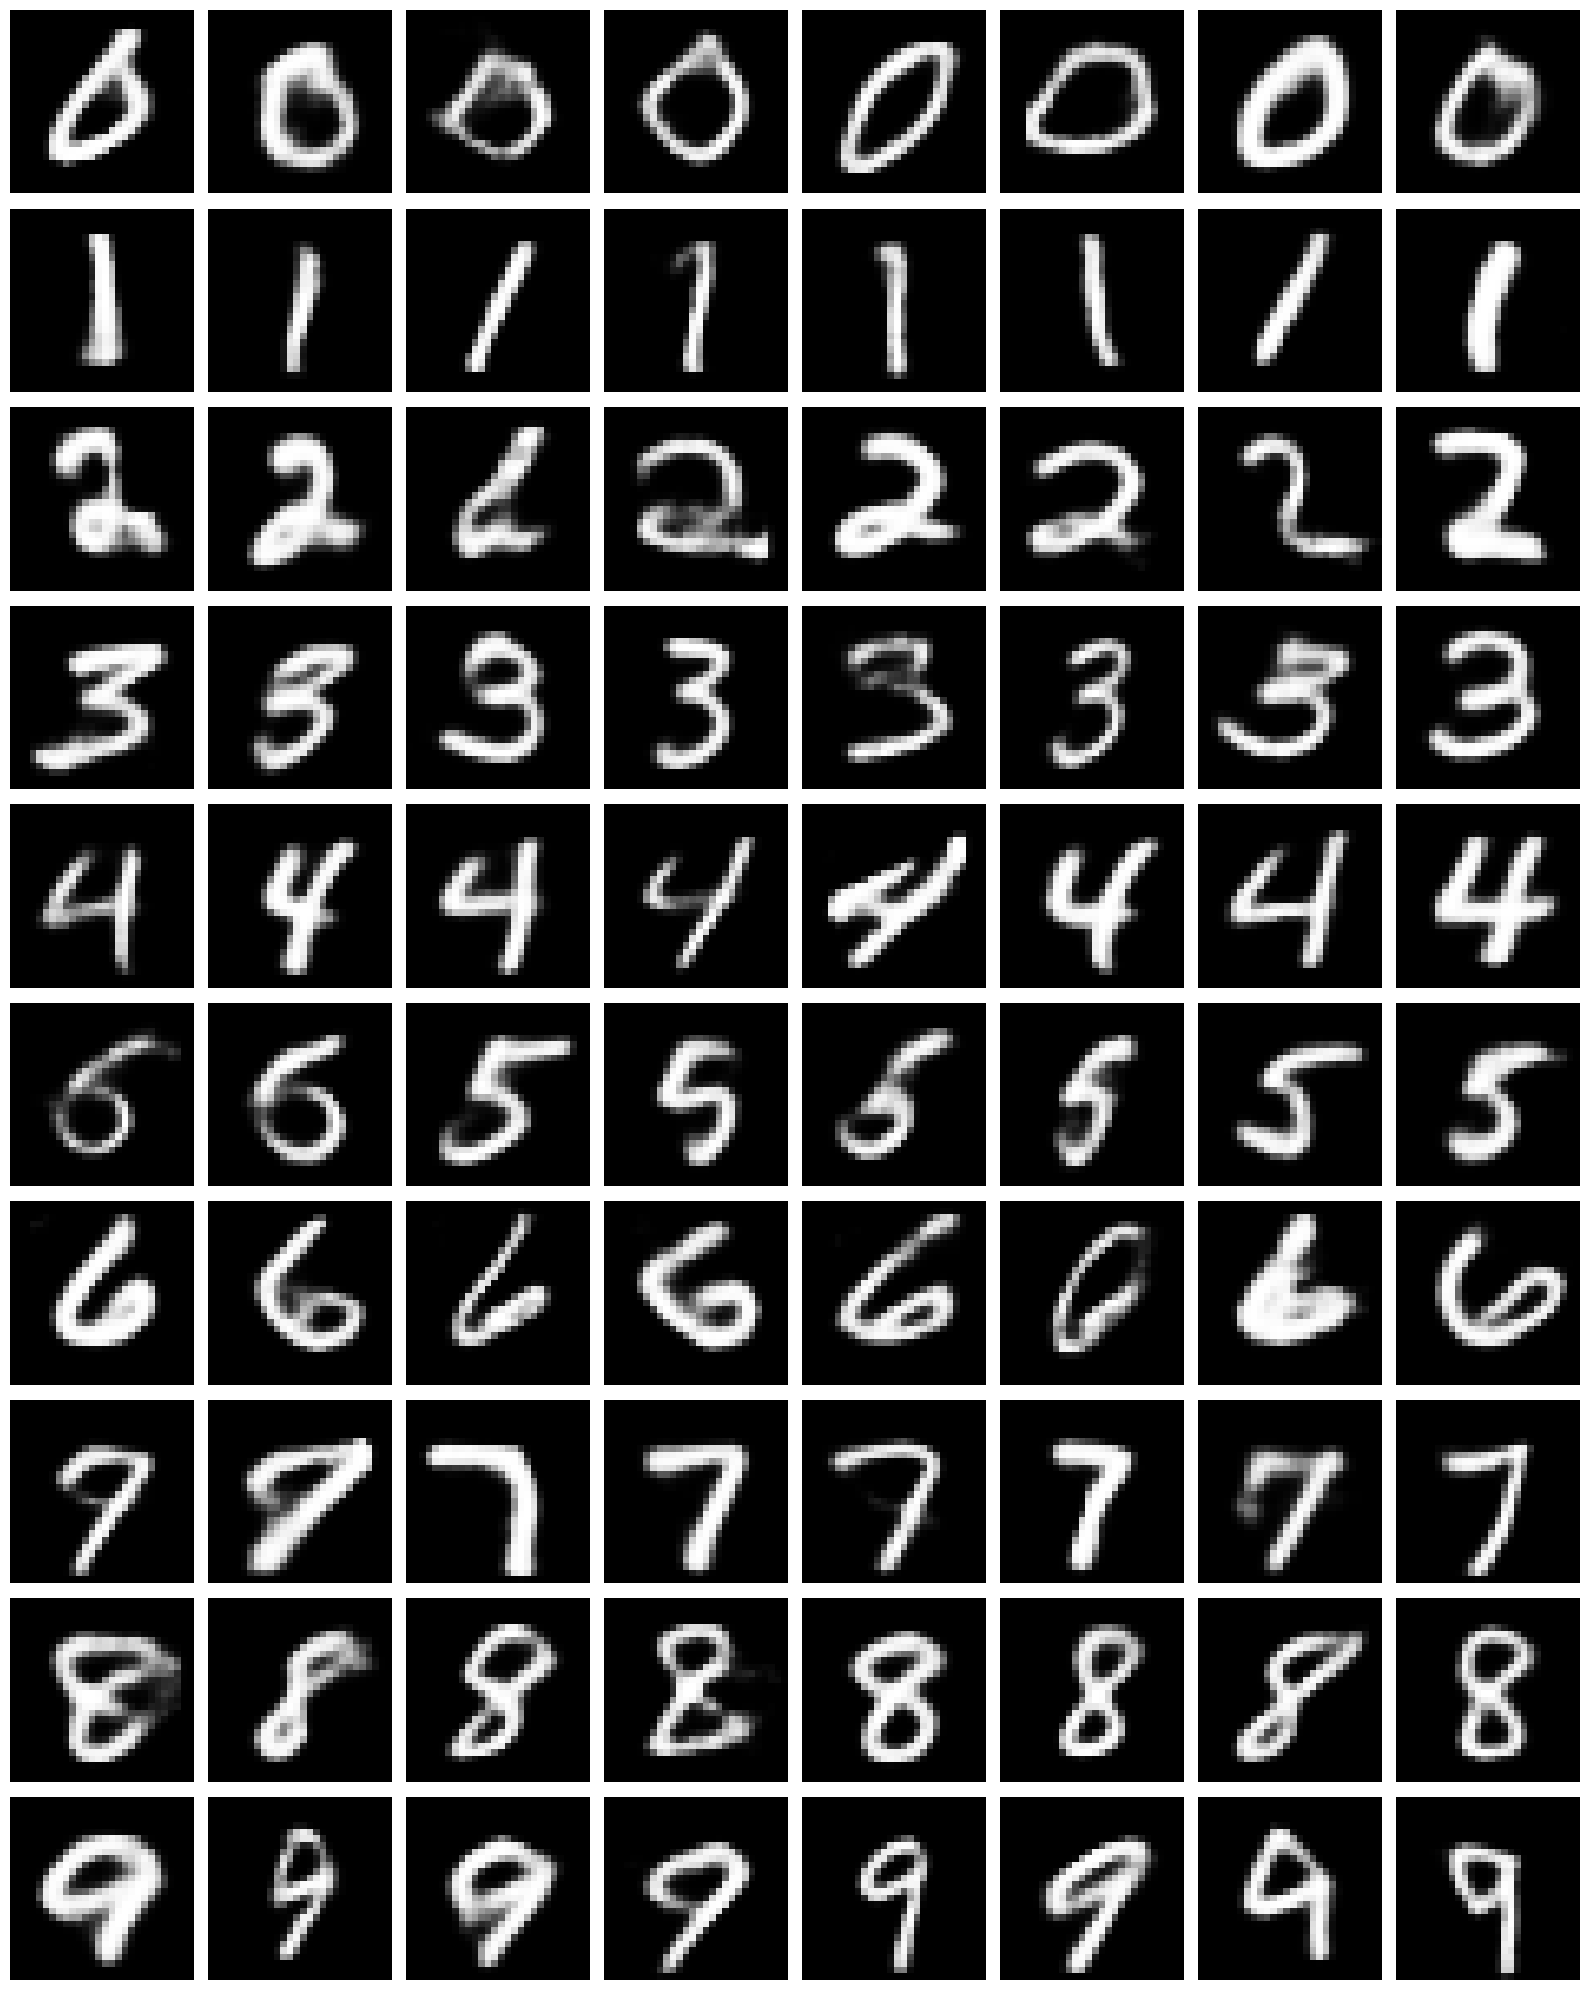

In [9]:
plot_model_samples(this_model, model_saved_path, latent_dim=20, num_classes=10, per_class=8, device=None)


# Paper Plot

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

# --- config ---
ROOT = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/")
sizes = [2000, 5000, 20000]

CSV_FILTER    = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/linear_increase/results_saved_more/results_table_500_40rounds.csv")
CSV_NO_FILTER = Path("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/schedule_size_linear_no_filter/results_saved_no_filter_more/results_table_500_40rounds.csv")

def parse_round(name: str):
    if "real_500" in name:
        return 0
    m = re.search(r"_r(\d+)", str(name))
    return int(m.group(1)) if m else None

def try_load_csv(path: Path, size, filtered: bool):
    try:
        df = pd.read_csv(path)
        df["round"] = df["model_name"].map(parse_round)
        df = df.dropna(subset=["round"]).sort_values("round")
        df["size"] = size
        df["filtered"] = filtered
        return df
    except Exception as e:
        print(f"[skip] {size} ({'filtered' if filtered else 'no-filter'}): {path} ({e})")
        return None

dfs = []

# fixed-size
for s in sizes:
    p_f = ROOT / f"fixed_size_{s}" / "results_saved_more/results_table_500_40rounds.csv"
    dfs.append(try_load_csv(p_f, s, True))
    p_nf = ROOT / f"schedule_size_{s}_no_filter/results_saved_no_filter_more/results_table_500_40rounds.csv"
    dfs.append(try_load_csv(p_nf, s, False))

# linear
dfs.append(try_load_csv(CSV_FILTER, "linear", True))
dfs.append(try_load_csv(CSV_NO_FILTER, "linear", False))

df_all = pd.concat([d for d in dfs if d is not None], ignore_index=True)


In [10]:
df_all_filtered = df_all[df_all["filtered"]==True]
df_all_filtered

,model_name,val_loss,val_recon,val_kl,fid,round,size,filtered
0,cvae_conv_real_500,121.043413,96.647541,24.395871,156.047012,0,linear,True
1,cvae_conv_init500_q0.1_s10000_r1,119.209046,96.144483,23.064563,109.925407,1,linear,True
2,cvae_conv_init500_q0.1_s16310_r2,118.343819,94.301627,24.042193,101.656975,2,linear,True
3,cvae_conv_init500_q0.1_s22620_r3,116.171028,92.196082,23.974946,93.667534,3,linear,True
4,cvae_conv_init500_q0.1_s28920_r4,115.305666,91.118068,24.187598,84.794365,4,linear,True
5,cvae_conv_init500_q0.1_s35230_r5,114.381367,90.702924,23.678444,74.820923,5,linear,True
6,cvae_conv_init500_q0.1_s41540_r6,113.681122,89.486558,24.194564,68.430519,6,linear,True
7,cvae_conv_init500_q0.1_s47850_r7,113.375506,88.934829,24.440677,60.298737,7,linear,True
8,cvae_conv_init500_q0.1_s54150_r8,113.663224,89.391259,24.271966,57.411968,8,linear,True
9,cvae_conv_init500_q0.1_s60460_r9,113.353879,88.820243,24.533635,49.338203,9,linear,True


In [2]:
from matplotlib.lines import Line2D
from cycler import cycler
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.35,
})

size_order = [2000, 5000, 20000, "linear"]

palette = mpl.cm.get_cmap("tab10")
size_to_color = {
    2000: palette(0),
    5000: palette(1),
    20000: palette(2),
    "linear": palette(3),
}

/tmp/ipykernel_3318909/1050092712.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = mpl.cm.get_cmap("tab10")


In [3]:
from matplotlib.lines import Line2D
from cycler import cycler
import matplotlib as mpl
import matplotlib.pyplot as plt

def plot_metric_pretty(metric: str, ylabel: str, savepath: str = None):
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    # 右侧预留画布空间给两个 legend
    plt.subplots_adjust(right=0.80)

    # 固定颜色循环
    ax.set_prop_cycle(cycler(color=[size_to_color[s] for s in size_order if s in df_all["size"].unique()]))

    # 画线（同色，不同线型）
    for s in size_order:
        sub_f  = df_all[(df_all["size"] == s) & (df_all["filtered"] == True)]
        sub_nf = df_all[(df_all["size"] == s) & (df_all["filtered"] == False)]
        if len(sub_f):
            ax.plot(sub_f["round"], sub_f[metric], "-",  lw=2.5, color=size_to_color[s])
        if len(sub_nf):
            ax.plot(sub_nf["round"], sub_nf[metric], "--", lw=2.5, color=size_to_color[s])

    # 轴与网格
    ax.set_xlabel("Iteration")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs Iteration")
    ax.grid(True, axis="both")

    # 四周边框
    for sp in ["left", "bottom", "top", "right"]:
        ax.spines[sp].set_visible(True)
        ax.spines[sp].set_linewidth(1.2)

    # ----- Legend A: Sample size（右上，带边框）-----
    size_handles = []
    for s in size_order:
        if s in df_all["size"].unique():
            if isinstance(s, int):  # 数字样本大小
                label = f"{s//1000}k"
            elif s == "linear":
                label = "Linear growth\n(10k→256k)"
            else:
                label = str(s)
            size_handles.append(Line2D([0],[0], color=size_to_color[s], lw=3, label=label))

    legend_sizes = fig.legend(
        handles=size_handles, title="VAE training sample size",
        loc="center left", bbox_to_anchor=(1, 0.76),  # 调整位置
        frameon=True, fancybox=True, borderpad=0.8, framealpha=1.0,
        title_fontsize=12, fontsize=12, bbox_transform=fig.transFigure
    )
    legend_sizes.set_zorder(5)

    # ----- Legend B: Line style（右中，带边框）-----
    ls_handles = [
        Line2D([0],[0], color="black", lw=2.5, linestyle="-",  label="Filtered"),
        Line2D([0],[0], color="black", lw=2.5, linestyle="--", label="Unfiltered"),
    ]
    legend_ls = fig.legend(
        handles=ls_handles, title="",
        loc="center left", bbox_to_anchor=(1, 0.48),
        frameon=True, fancybox=True, borderpad=0.8, framealpha=1.0,
        title_fontsize=12, fontsize=12, bbox_transform=fig.transFigure
    )
    legend_ls.set_zorder(5)

    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=600, bbox_inches="tight", transparent=True)
    plt.show()


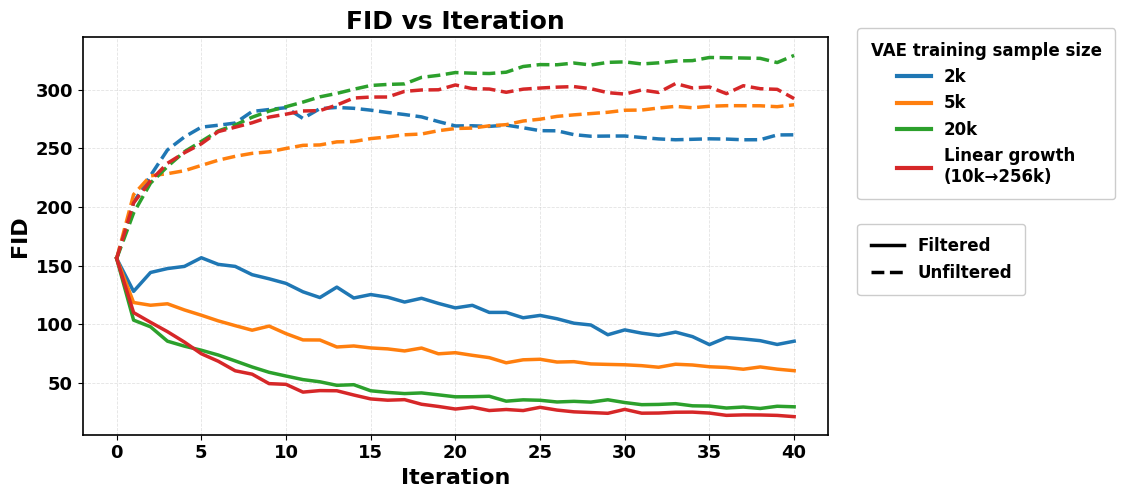

In [5]:
plot_metric_pretty("fid", "FID", savepath="/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/FID.pdf")

In [7]:
result_256 = pd.read_csv("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_256_000/results_saved_more/results_table_500_40rounds.csv")
result_128 = pd.read_csv("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_128_000/results_saved_more/results_table_500_40rounds.csv")
result_32 = pd.read_csv("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_32_000/results_saved_more/results_table_500_60rounds.csv")

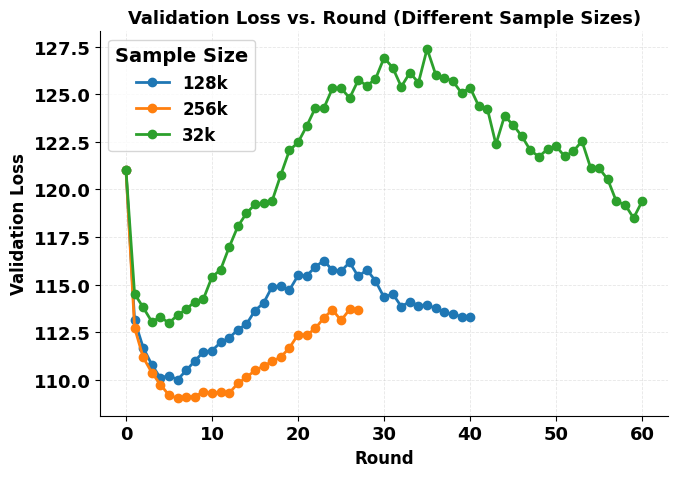

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# ------------------------------
# Load all results
# ------------------------------
result_32  = pd.read_csv("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_32_000/results_saved_more/results_table_500_60rounds.csv")
result_128 = pd.read_csv("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_128_000/results_saved_more/results_table_500_40rounds.csv")
result_256 = pd.read_csv("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fixed_size_256_000/results_saved_more/results_table_500_40rounds.csv")

# ------------------------------
# Add size label
# ------------------------------
result_32["size"]  = "32k"
result_128["size"] = "128k"
result_256["size"] = "256k"

# Combine
df = pd.concat([result_32, result_128, result_256], ignore_index=True)

# ------------------------------
# Extract round number from model_name
# ------------------------------
def extract_round(name):
    m = re.search(r"_r(\d+)", str(name))
    return int(m.group(1)) if m else 0  # 0 = real baseline

df["round"] = df["model_name"].apply(extract_round)

# Sort by round
df = df.sort_values(["size", "round"])

# ------------------------------
# Plot val_loss vs round
# ------------------------------
plt.figure(figsize=(7,5))
for size, sub in df.groupby("size"):
    plt.plot(sub["round"], sub["val_loss"], marker="o", lw=2, label=size)

plt.xlabel("Round", fontsize=12)
plt.ylabel("Validation Loss", fontsize=12)
plt.title("Validation Loss vs. Round (Different Sample Sizes)", fontsize=13)
plt.legend(title="Sample Size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
df_all

,model_name,val_loss,val_recon,val_kl,fid,size
0,cvae_conv_real_500,121.043843,96.648644,24.395199,156.047943,32k
1,cvae_conv_init500_q0.1_s32000_r1,114.523141,91.422305,23.100836,96.310783,32k
2,cvae_conv_init500_q0.1_s32000_r2,113.807067,90.892560,22.914507,89.831818,32k
3,cvae_conv_init500_q0.1_s32000_r3,113.059038,89.796986,23.262052,82.565170,32k
4,cvae_conv_init500_q0.1_s32000_r4,113.293714,89.491417,23.802297,77.580933,32k
...,...,...,...,...,...,...
125,cvae_conv_init500_q0.1_s256000_r23,113.256892,90.409684,22.847209,24.288929,256k
126,cvae_conv_init500_q0.1_s256000_r24,113.687505,90.966252,22.721253,24.058922,256k
127,cvae_conv_init500_q0.1_s256000_r25,113.123910,90.493816,22.630093,23.401230,256k
128,cvae_conv_init500_q0.1_s256000_r26,113.704252,91.206497,22.497754,22.882431,256k


In [6]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

def plot_linear_filtered(metric: str, ylabel: str, savepath: str = None):
    fig, ax = plt.subplots(figsize=(8.6, 5.2))

    sub = df_all[(df_all["size"] == "linear") & (df_all["filtered"] == True)]
    if len(sub):
        ax.plot(
            sub["round"], sub[metric],
            "-", lw=2.5, color=size_to_color["linear"],
            label="Linear growth (10k→256k, filtered)"
        )

    ax.set_xlabel("Iteration")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs Iteration")
    ax.grid(True, axis="both")

    for sp in ["left", "bottom", "top", "right"]:
        ax.spines[sp].set_visible(True)
        ax.spines[sp].set_linewidth(1.2)

    ax.legend(frameon=True, fancybox=True, fontsize=12)

    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=600, bbox_inches="tight", transparent=True)
    plt.show()


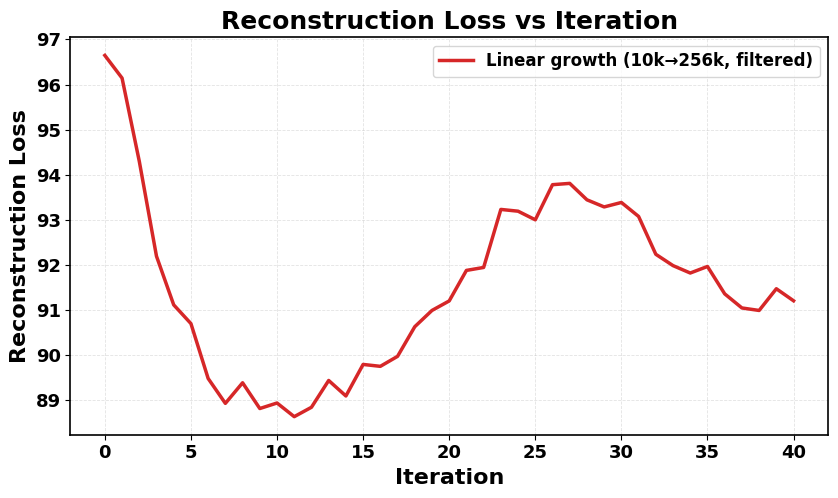

In [ ]:
plot_linear_filtered("val_recon", "Reconstruction Loss")

In [7]:
import os
import re
import glob
import pandas as pd
from matplotlib.lines import Line2D
from cycler import cycler
import matplotlib.pyplot as plt
import matplotlib as mpl
# ====== 路径：把这里改成包含 dic_* / fixed_size_* 的父目录 ======
ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/"

CSV_GLOBS = [
    "results_saved_more/*.csv",
    "*.csv",
]
mpl.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.35,
})


# 若某些目录需要“手工指定”verifier 样本量，可在此覆盖
OVERRIDE_VERIFIER_SIZE = {
    "fixed_size_20000": 60000,   # 你说的这组：verifier 用 60000
    # 如果将来还有别的： "fixed_size_XXXX": 某值,
}

def _find_first_csv(subdir):
    for pat in CSV_GLOBS:
        hits = glob.glob(os.path.join(subdir, pat))
        if hits:
            hits.sort(key=lambda p: ("results_table" not in os.path.basename(p), p))
            return hits[0]
    return None

def _parse_round(model_name: str) -> int:
    m = re.search(r"_r(\d+)", str(model_name))
    return int(m.group(1)) if m else 0

def _parse_filtered(model_name: str):
    # 本任务：只关心 filtered 数据；若名字里含 no_filter 则标 False，否则 True。
    name = str(model_name).lower()
    if "no_filter" in name:
        return False
    if "real" in name:
        return None  # baseline，不参与曲线
    return True

def _parse_verifier_size_from_dir(dirname: str):
    """dic_500 -> 500；fixed_size_20000 -> 依据 OVERRIDE（此处为 60000）"""
    base = os.path.basename(dirname)
    if base in OVERRIDE_VERIFIER_SIZE:
        return OVERRIDE_VERIFIER_SIZE[base]
    m = re.search(r"^dic_(\d+)$", base)
    if m:
        return int(m.group(1))
    # 其他命名返回 None（将被跳过）
    return None

# ====== 读取全部结果并整合 ======
rows = []
for entry in os.scandir(ROOT):
    if not entry.is_dir():
        continue

    verifier_size = _parse_verifier_size_from_dir(entry.name)
    if verifier_size is None:
        continue

    csv_path = _find_first_csv(entry.path)
    if not csv_path:
        print(f"[WARN] No CSV under: {entry.path}")
        continue

    df = pd.read_csv(csv_path)
    if "model_name" not in df.columns:
        print(f"[WARN] CSV missing 'model_name': {csv_path}")
        continue

    for _, r in df.iterrows():
        model_name = r["model_name"]
        rnd = _parse_round(model_name)
        filtered = _parse_filtered(model_name)
        rows.append({
            "verifier_size": verifier_size,
            "round": rnd,
            "filtered": filtered,
            **{k: r[k] for k in df.columns if k != "model_name"}
        })

df_all = pd.DataFrame(rows)

# 只保留 filtered==True
df_all = df_all[df_all["filtered"] == True].copy()

# 若某些 CSV 没有 val_* 或 fid 列，不会影响其他图的绘制
verifier_order = sorted(df_all["verifier_size"].unique())

# 配色
default_colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
if len(default_colors) < len(verifier_order):
    import itertools
    default_colors = list(itertools.islice(itertools.cycle(default_colors), len(verifier_order)))
verifier_to_color = {s: default_colors[i] for i, s in enumerate(verifier_order)}

def _fmt_size_label(n):
    return f"{n//1000}k" if n >= 1000 else f"{n}"


from matplotlib.lines import Line2D
from cycler import cycler
import matplotlib.pyplot as plt

def plot_metric_pretty_filtered(metric: str, ylabel: str, savepath: str=None, first_round:int=1):
    if metric not in df_all.columns:
        print(f"[WARN] metric '{metric}' not in dataframe columns.")
        return

    # --- global mean for the first round (filtered only) ---
    mask_r1 = (df_all["round"] == first_round)
    r1_mean = df_all.loc[mask_r1, metric].mean() if mask_r1.any() else None
    if r1_mean is None:
        print(f"[WARN] no rows with round=={first_round} for metric '{metric}'.")

    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    plt.subplots_adjust(right=0.80)

    # fixed color cycle (by verifier size)
    ax.set_prop_cycle(cycler(color=[verifier_to_color[s] for s in verifier_order]))

    # draw lines (filtered only)
    for s in verifier_order:
        sub = df_all[df_all["verifier_size"] == s].sort_values("round").copy()
        if len(sub) == 0:
            continue
        if r1_mean is not None:
            idx = (sub["round"] == first_round)
            if idx.any():
                sub.loc[idx, metric] = r1_mean
        ax.plot(sub["round"], sub[metric], "-", lw=2.5, color=verifier_to_color[s])

    # axes, grid, frame
    ax.set_xlabel("Model-Fitting Iteration")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs Model-Fitting Iteration (Filtered only)")
    ax.grid(True, axis="both")
    for sp in ["left", "bottom", "top", "right"]:
        ax.spines[sp].set_visible(True)
        ax.spines[sp].set_linewidth(1.2)

    # ---------- Legend (match size/placement; make bold) ----------
    def _fmt_size_label(n):
        return f"{n//1000}k" if n >= 1000 else f"{n}"

    size_handles = [
        Line2D([0],[0], color=verifier_to_color[s], lw=2.5, label=_fmt_size_label(s))
        for s in verifier_order
    ]

    legend_sizes = fig.legend(
        handles=size_handles,
        title="Verifier training sample size",
        loc="center left",
        bbox_to_anchor=(1, 0.7),              # same placement as your reference
        frameon=True, fancybox=True, borderpad=0.8, framealpha=1.0,
        title_fontsize=12, fontsize=12,        # same sizes as reference
        bbox_transform=fig.transFigure
    )
    legend_sizes.set_zorder(5)
    # bold legend title & texts
    legend_sizes.get_title().set_fontweight("bold")
    for text in legend_sizes.get_texts():
        text.set_fontweight("bold")

    ax.set_xlabel("Model-Fitting Iteration", fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(f"{ylabel} vs Model-Fitting Iteration",
                 fontweight="bold")
    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=600, bbox_inches="tight", transparent=True)
    plt.show()


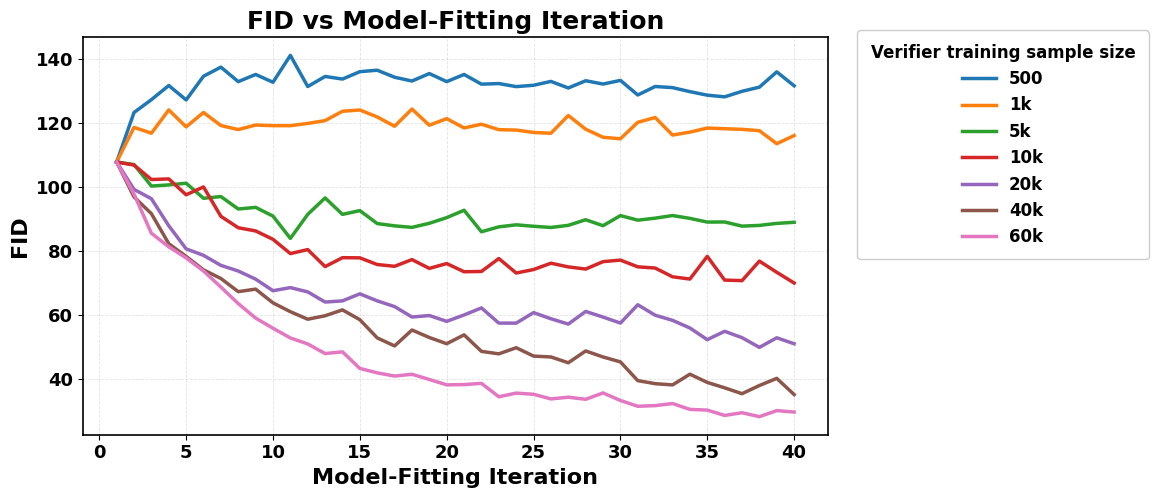

In [8]:
plot_metric_pretty_filtered("fid", "FID",savepath="/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/verifier.pdf")

/tmp/ipykernel_3342946/596766982.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=device))


[INFO] Model loaded from /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/model_saved_full_dataset/full_dataset_model.pth
[SAVE] Sample grid saved -> /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/picture_saved_more/full_dataset_model_samples.png


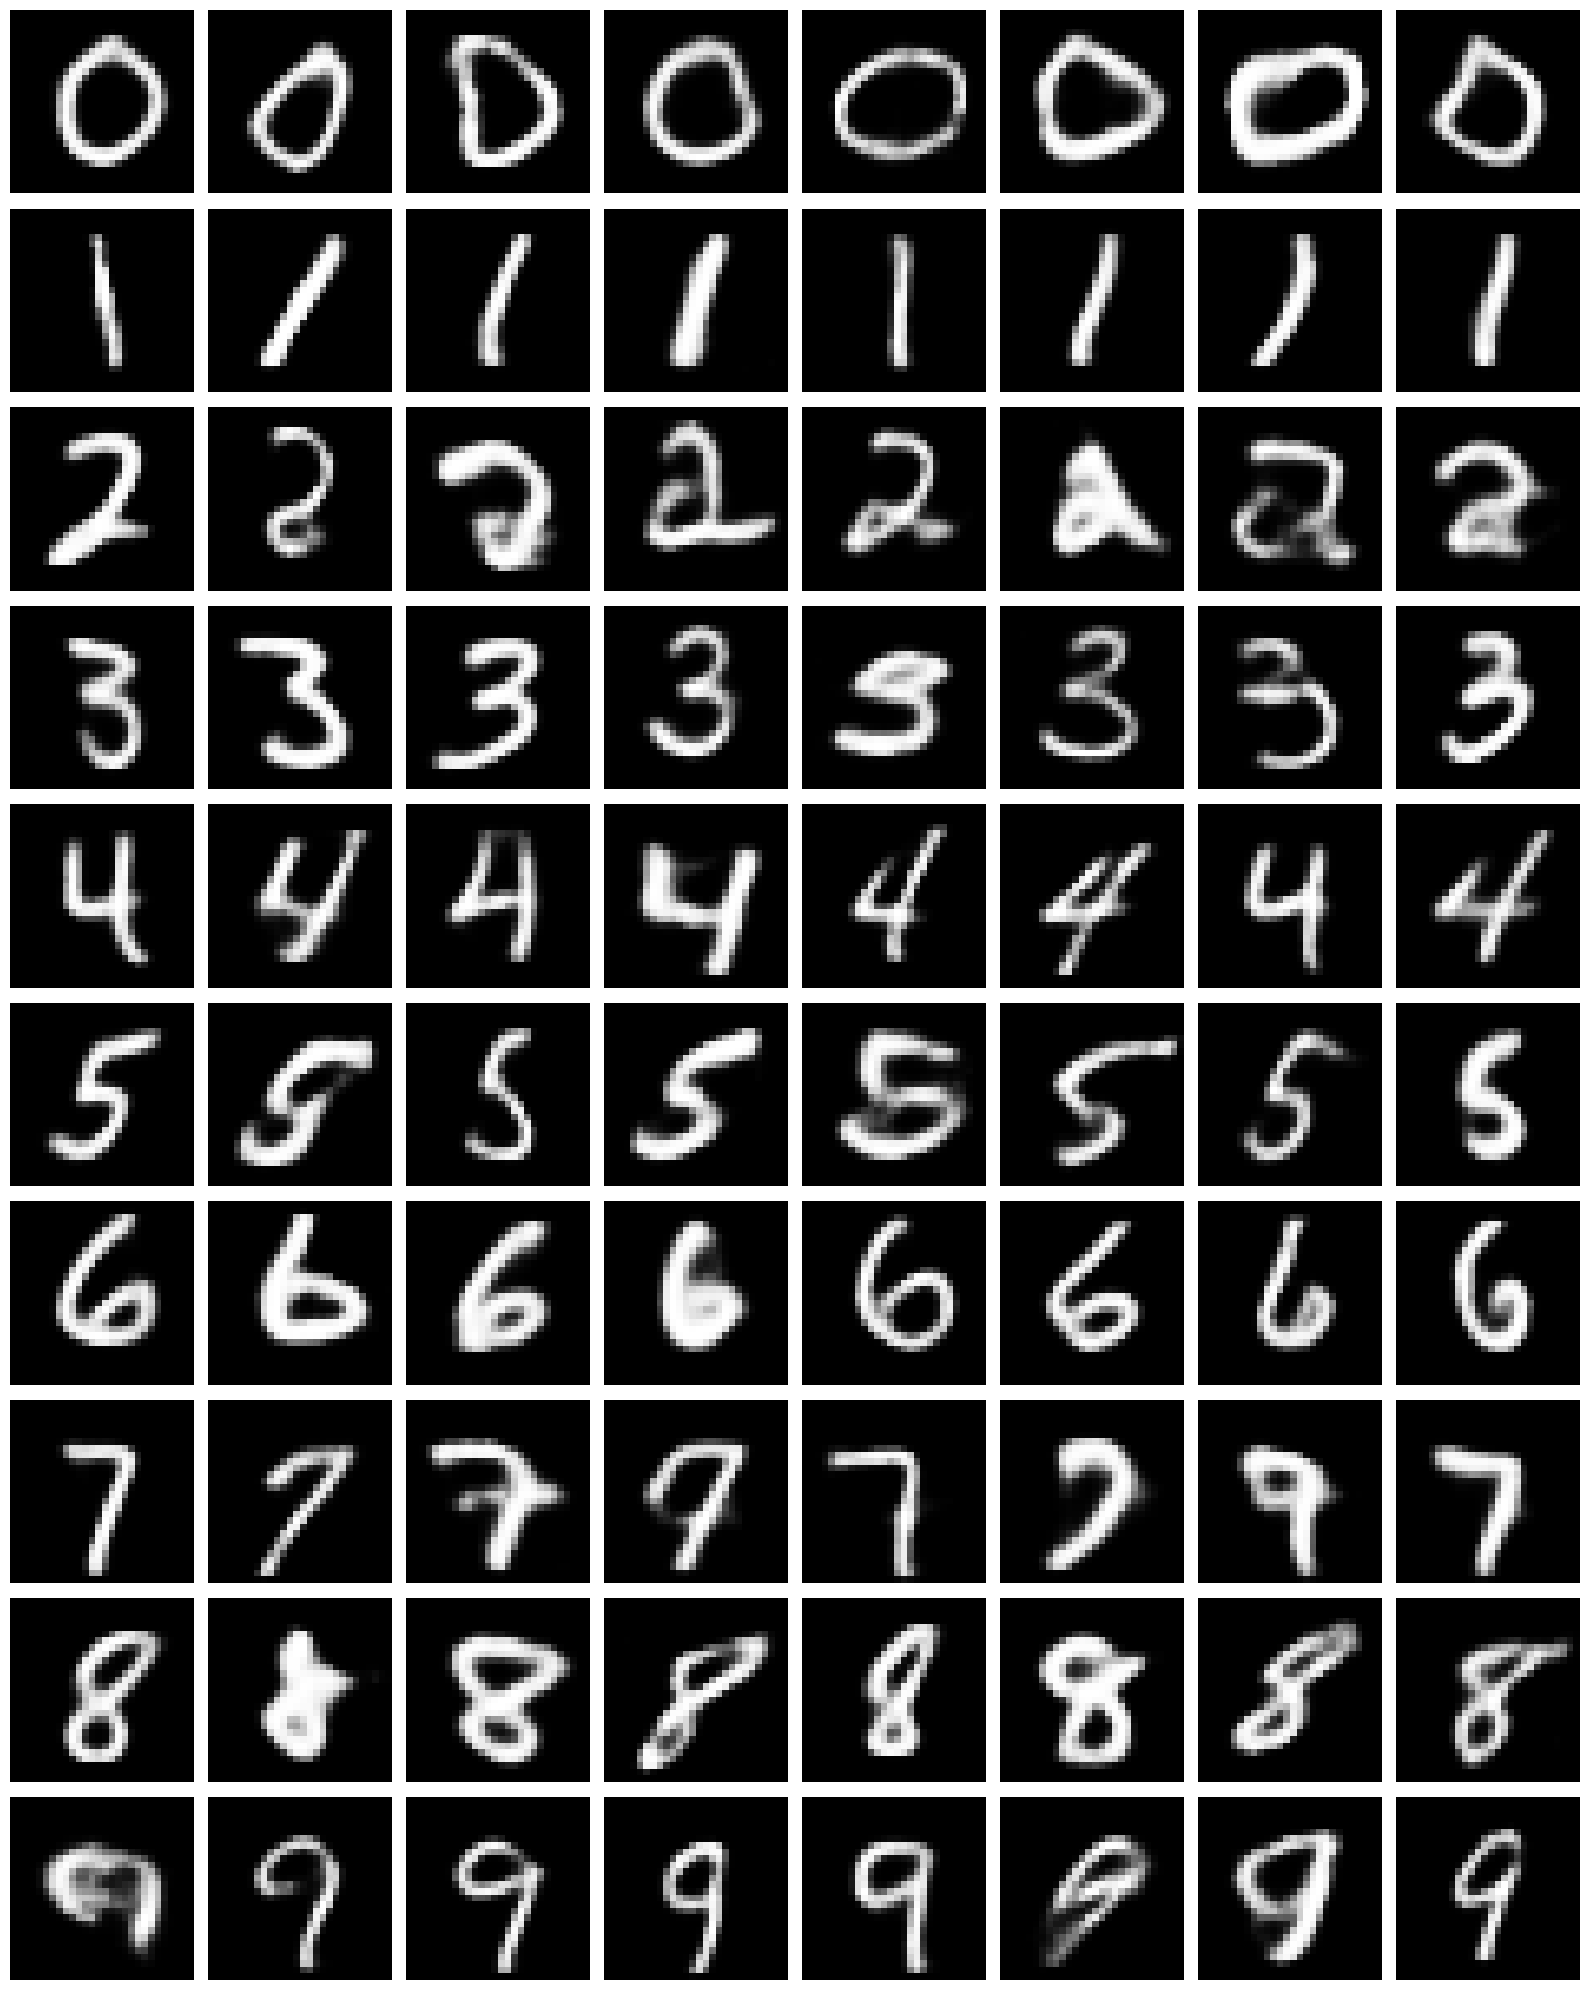

(<Figure size 1600x2000 with 80 Axes>,
 array([[<Axes: ylabel='Class 0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 7'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='Class 8'>, <Axes:

In [1]:
# =========================================================
# 🧠 Draw Samples from Full-Dataset CVAE (Same Style as plot_model_samples)
# =========================================================

import os, sys, torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 路径和参数
# -----------------------------
vae_path = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae"
model_saved_path1 = os.path.join(vae_path, "model_saved_full_dataset")
ckpt_path = os.path.join(model_saved_path1, "full_dataset_model.pth")

latent_dim = 20
num_classes = 10
per_class = 8  # 每类显示几张
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 导入自定义模块
# -----------------------------
sys.path.append(vae_path)
import models  # 来自你项目的 models.py

# -----------------------------
# 加载模型
# -----------------------------
model = models.CVAE(input_dim=784, label_dim=num_classes, latent_dim=latent_dim, arch="conv").to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()
print(f"[INFO] Model loaded from {ckpt_path}")

# =========================================================
# 与原代码相同的绘图函数
# =========================================================
@torch.no_grad()
def plot_model_samples(model, save_path=None, latent_dim=20, num_classes=10, per_class=8, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()

    # latent + labels
    z = torch.randn(num_classes * per_class, latent_dim, device=device)
    y = torch.arange(num_classes, device=device).repeat_interleave(per_class)
    y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

    # decode -> logits, then sigmoid 映射到 [0,1]
    logits_flat = model.decoder.decode(z, y_onehot)
    imgs = torch.sigmoid(logits_flat).view(-1, 1, 28, 28)

    # 转换为 numpy 以便绘制
    imgs_np = imgs.detach().cpu().numpy()

    # 与你脚本中相同的格式
    fig, axes = plt.subplots(num_classes, per_class, figsize=(2 * per_class, 2 * num_classes))
    for c in range(num_classes):
        for j in range(per_class):
            idx = c * per_class + j
            axes[c, j].imshow(imgs_np[idx].squeeze(), cmap="gray")
            axes[c, j].axis("off")
            if j == 0:
                axes[c, j].set_ylabel(f"Class {c}", fontsize=10)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150)
        print(f"[SAVE] Sample grid saved -> {save_path}")
    plt.show()
    return fig, axes

# -----------------------------
# 生成并保存样本
# -----------------------------
save_path = os.path.join(vae_path, "picture_saved_more/full_dataset_model_samples.png")
plot_model_samples(model, save_path=save_path, latent_dim=latent_dim, num_classes=num_classes, per_class=per_class, device=device)


# New FID plot


In [7]:
df_all

,model_name,val_loss,val_recon,val_kl,fid,round,size,filtered
0,cvae_conv_real_500,121.043344,96.647575,24.395769,156.053146,0,2000,True
1,cvae_conv_init500_q0.1_s2000_r1,135.833487,109.176114,26.657373,128.030609,1,2000,True
2,cvae_conv_init500_q0.1_s2000_r2,158.229937,129.939967,28.289970,144.137650,2,2000,True
3,cvae_conv_init500_q0.1_s2000_r3,171.572511,142.474650,29.097862,147.485779,3,2000,True
4,cvae_conv_init500_q0.1_s2000_r4,187.402122,159.924925,27.477197,149.319824,4,2000,True
...,...,...,...,...,...,...,...,...
323,cvae_conv_init500_q1_230770_r36,151.271952,126.147173,25.124779,296.675842,36,linear,False
324,cvae_conv_init500_q1_237080_r37,152.313076,127.364192,24.948885,303.439728,37,linear,False
325,cvae_conv_init500_q1_243380_r38,152.433519,127.221121,25.212398,300.886566,38,linear,False
326,cvae_conv_init500_q1_249690_r39,153.380011,129.149231,24.230779,300.349213,39,linear,False


In [9]:
df_all

,model_file,round,mnist_fid_v2_fixed,num_synth,filtered,size,exp_name
0,cvae_conv_init500_q0.1_s2000_r1.pth,1,135.541924,6000,True,2000,fixed_size_2000_filtered
1,cvae_conv_init500_q0.1_s2000_r10.pth,10,137.146241,6000,True,2000,fixed_size_2000_filtered
2,cvae_conv_init500_q0.1_s2000_r11.pth,11,132.540076,6000,True,2000,fixed_size_2000_filtered
3,cvae_conv_init500_q0.1_s2000_r12.pth,12,126.064210,6000,True,2000,fixed_size_2000_filtered
4,cvae_conv_init500_q0.1_s2000_r13.pth,13,128.966016,6000,True,2000,fixed_size_2000_filtered
...,...,...,...,...,...,...,...
323,cvae_conv_init500_q1_79380_r12.pth,12,1654.055826,6000,False,linear,linear_no_filter
324,cvae_conv_init500_q1_85690_r13.pth,13,1766.122470,6000,False,linear,linear_no_filter
325,cvae_conv_init500_q1_92000_r14.pth,14,1917.740679,6000,False,linear,linear_no_filter
326,cvae_conv_init500_q1_98310_r15.pth,15,1932.770329,6000,False,linear,linear_no_filter


In [10]:
df_all_round0 = df_all[df_all["round"]==0]

In [11]:
df_all_round0

,model_file,round,mnist_fid_v2_fixed,num_synth,filtered,size,exp_name
40,cvae_conv_real_500.pth,0,447.794393,6000,True,2000,fixed_size_2000_filtered
81,cvae_conv_real_500.pth,0,461.062392,6000,False,2000,schedule_size_2000_no_filter
122,cvae_conv_real_500.pth,0,453.202046,6000,True,5000,fixed_size_5000_filtered
163,cvae_conv_real_500.pth,0,443.176872,6000,False,5000,schedule_size_5000_no_filter
204,cvae_conv_real_500.pth,0,437.777918,6000,True,20000,fixed_size_20000_filtered
245,cvae_conv_real_500.pth,0,445.407250,6000,False,20000,schedule_size_20000_no_filter
286,cvae_conv_real_500.pth,0,429.649464,6000,True,linear,linear_filtered
327,cvae_conv_real_500.pth,0,436.571816,6000,False,linear,linear_no_filter


/tmp/ipykernel_706244/1839399021.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = mpl.cm.get_cmap("tab10")


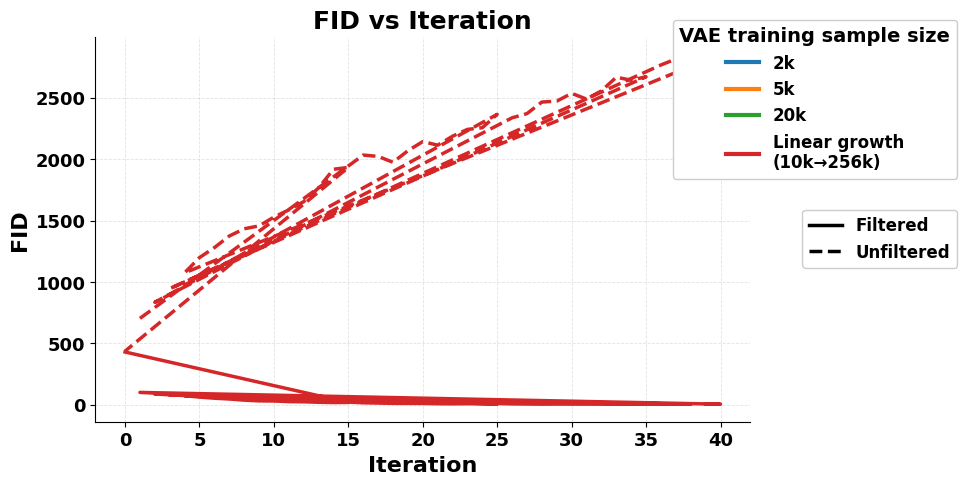

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from cycler import cycler

# ======================
# 0. 全局风格设置（与你图一致）
# ======================
mpl.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.35,
})

# 颜色顺序必须和你图完全一致
palette = mpl.cm.get_cmap("tab10")
size_order = [2000, 5000, 20000, "linear"]
size_to_color = {
    2000: palette(0),
    5000: palette(1),
    20000: palette(2),
    "linear": palette(3),
}

# ======================
# 1. Load CSV
# ======================
df_path = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_fid_v2_fixed_all_experiments.csv"
df = pd.read_csv(df_path)

# parse boolean correctly
df["filtered"] = df["filtered"].astype(str).str.lower().map(
    {"true": True, "1": True, "false": False, "0": False}
)

# 如果线性增长用 exp_name 判断
df.loc[df["exp_name"].str.contains("linear"), "size"] = "linear"

# ======================
# 2. Start plotting
# ======================
fig, ax = plt.subplots(figsize=(10, 5))
plt.subplots_adjust(right=0.78)

ax.set_xlabel("Iteration")
ax.set_ylabel("FID")
ax.set_title("FID vs Iteration")

ax.grid(True)

# 设置颜色循环
ax.set_prop_cycle(cycler(color=[size_to_color[s] for s in size_order]))

# ======================
# 3. 画 4 条 filtered + 4 条 unfiltered
# ======================
for s in size_order:
    sub_f = df[(df["size"] == s) & (df["filtered"] == True)]
    sub_u = df[(df["size"] == s) & (df["filtered"] == False)]
    if len(sub_f):
        ax.plot(sub_f["round"], sub_f["mnist_fid_v2_fixed"],
                "-", lw=2.5, color=size_to_color[s])
    if len(sub_u):
        ax.plot(sub_u["round"], sub_u["mnist_fid_v2_fixed"],
                "--", lw=2.5, color=size_to_color[s])

# ======================
# 4. Legend: sample sizes（右上）
# ======================
handles_sizes = []
for s in size_order:
    if s == 2000:
        label = "2k"
    elif s == 5000:
        label = "5k"
    elif s == 20000:
        label = "20k"
    else:
        label = "Linear growth\n(10k→256k)"

    handles_sizes.append(
        Line2D([0], [0], lw=3, color=size_to_color[s], label=label)
    )

legend_sizes = fig.legend(
    handles=handles_sizes,
    title="VAE training sample size",
    loc="upper right",
    bbox_to_anchor=(0.995, 0.93),
    frameon=True,
    fancybox=True,
    framealpha=1.0
)

# ======================
# 5. Legend: line types（右中）
# ======================
handles_ls = [
    Line2D([0], [0], color="black", lw=2.5, linestyle="-", label="Filtered"),
    Line2D([0], [0], color="black", lw=2.5, linestyle="--", label="Unfiltered"),
]

legend_ls = fig.legend(
    handles=handles_ls,
    loc="upper right",
    bbox_to_anchor=(0.995, 0.55),
    frameon=True,
    fancybox=True,
    framealpha=1.0
)

plt.show()


/tmp/ipykernel_706244/145710034.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = mpl.cm.get_cmap("tab10")


Unique sizes: [2000 5000 20000 'linear']
Counts by size, filtered:
size    filtered
2000    False       41
        True        41
5000    False       41
        True        41
20000   False       41
        True        41
linear  False       41
        True        41
dtype: int64


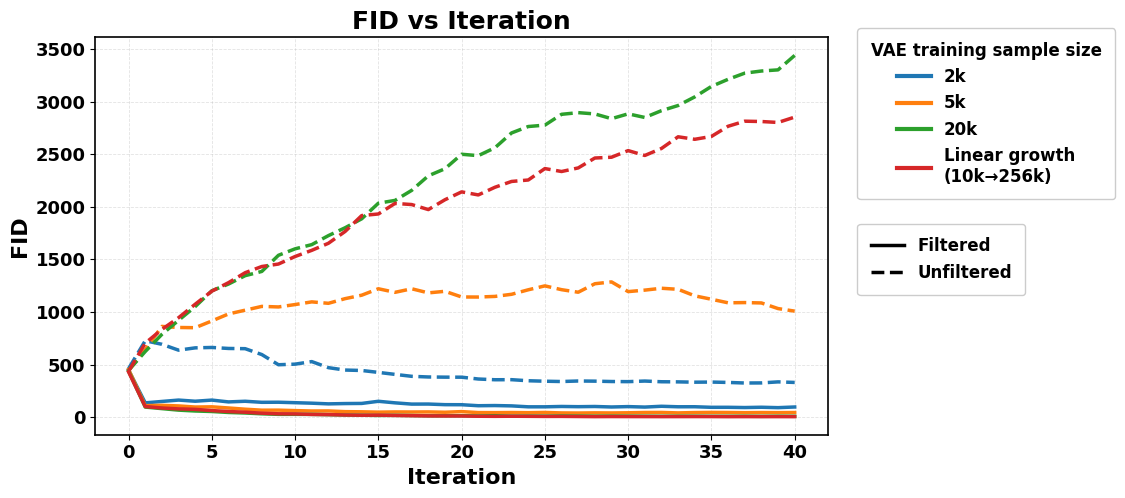

In [18]:
import re
import pandas as pd
from matplotlib.lines import Line2D
from cycler import cycler
import matplotlib as mpl
import matplotlib.pyplot as plt

# ------------------------------------------------
# 0. Global style (same as before)
# ------------------------------------------------
mpl.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.35,
})

size_order = [2000, 5000, 20000, "linear"]
palette = mpl.cm.get_cmap("tab10")
size_to_color = {
    2000:   palette(0),
    5000:   palette(1),
    20000:  palette(2),
    "linear": palette(3),
}

# ------------------------------------------------
# 1. Load CSV
# ------------------------------------------------
csv_path = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/mnist_fid_v2_fixed_all_experiments.csv"
df_all = pd.read_csv(csv_path)

# ------------------------------------------------
# 2. Parse size & filtered from exp_name
#    支持：
#      fixed_size_2000_filtered
#      schedule_size_5000_no_filter
#      linear_filtered / linear_no_filter
# ------------------------------------------------
def extract_size(exp_name: str):
    exp_name = str(exp_name)
    # linear runs
    if "linear" in exp_name:
        return "linear"
    # fixed_size_XXXX or schedule_size_XXXX
    m = re.search(r"(fixed_size_|schedule_size_)(\d+)", exp_name)
    if m:
        return int(m.group(2))
    return None

df_all["size"] = df_all["exp_name"].apply(extract_size)

# filtered 标记：名字里包含 "_no_filter" 则 False；否则只要有 "filtered" 就当 True
exp = df_all["exp_name"].astype(str)
df_all["filtered"] = exp.str.contains("filtered") & ~exp.str.contains("no_filter")

print("Unique sizes:", df_all["size"].unique())
print("Counts by size, filtered:")
print(df_all.groupby(["size", "filtered"]).size())

# 如果还有 size=None 的行（比如别的实验），可以选择丢掉
df_all = df_all[df_all["size"].notna()].copy()

# ------------------------------------------------
# 3. Plot function
# ------------------------------------------------
def plot_metric_pretty(metric: str, ylabel: str, savepath: str = None):
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    plt.subplots_adjust(right=0.80)

    unique_sizes = df_all["size"].unique()
    ax.set_prop_cycle(
        cycler(color=[size_to_color[s] for s in size_order if s in unique_sizes])
    )

    # same color, solid=filtered, dashed=unfiltered
    for s in size_order:
        if s not in unique_sizes:
            continue

        sub_f  = df_all[(df_all["size"] == s) & (df_all["filtered"] == True)].sort_values("round")
        sub_nf = df_all[(df_all["size"] == s) & (df_all["filtered"] == False)].sort_values("round")

        if len(sub_f):
            ax.plot(sub_f["round"], sub_f[metric], "-",  lw=2.5, color=size_to_color[s])
        if len(sub_nf):
            ax.plot(sub_nf["round"], sub_nf[metric], "--", lw=2.5, color=size_to_color[s])

    ax.set_xlabel("Iteration")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs Iteration")
    ax.grid(True, axis="both")

    for sp in ["left", "bottom", "top", "right"]:
        ax.spines[sp].set_visible(True)
        ax.spines[sp].set_linewidth(1.2)

    # ----- Legend A: sample size -----
    size_handles = []
    for s in size_order:
        if s in unique_sizes:
            if isinstance(s, int):
                label = f"{s // 1000}k"
            elif s == "linear":
                label = "Linear growth\n(10k→256k)"
            else:
                label = str(s)
            size_handles.append(Line2D([0], [0], color=size_to_color[s], lw=3, label=label))

    legend_sizes = fig.legend(
        handles=size_handles,
        title="VAE training sample size",
        loc="center left",
        bbox_to_anchor=(1, 0.76),
        frameon=True,
        fancybox=True,
        borderpad=0.8,
        framealpha=1.0,
        title_fontsize=12,
        fontsize=12,
        bbox_transform=fig.transFigure,
    )
    legend_sizes.set_zorder(5)

    # ----- Legend B: line style -----
    ls_handles = [
        Line2D([0], [0], color="black", lw=2.5, linestyle="-",  label="Filtered"),
        Line2D([0], [0], color="black", lw=2.5, linestyle="--", label="Unfiltered"),
    ]
    legend_ls = fig.legend(
        handles=ls_handles,
        title="",
        loc="center left",
        bbox_to_anchor=(1, 0.48),
        frameon=True,
        fancybox=True,
        borderpad=0.8,
        framealpha=1.0,
        title_fontsize=12,
        fontsize=12,
        bbox_transform=fig.transFigure,
    )
    legend_ls.set_zorder(5)

    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=600, bbox_inches="tight", transparent=True)
    plt.show()

# ------------------------------------------------
# 4. Draw the figure
# ------------------------------------------------
plot_metric_pretty(
    metric="mnist_fid_v2_fixed",
    ylabel="FID",
    savepath="/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/new_fid_v2_fixed.pdf",
)


In [ ]:
df_

[2000 None 5000 20000 'linear']
[ True False]
size    filtered
2000    True        41
5000    True        41
20000   True        41
linear  False       41
        True        41
dtype: int64


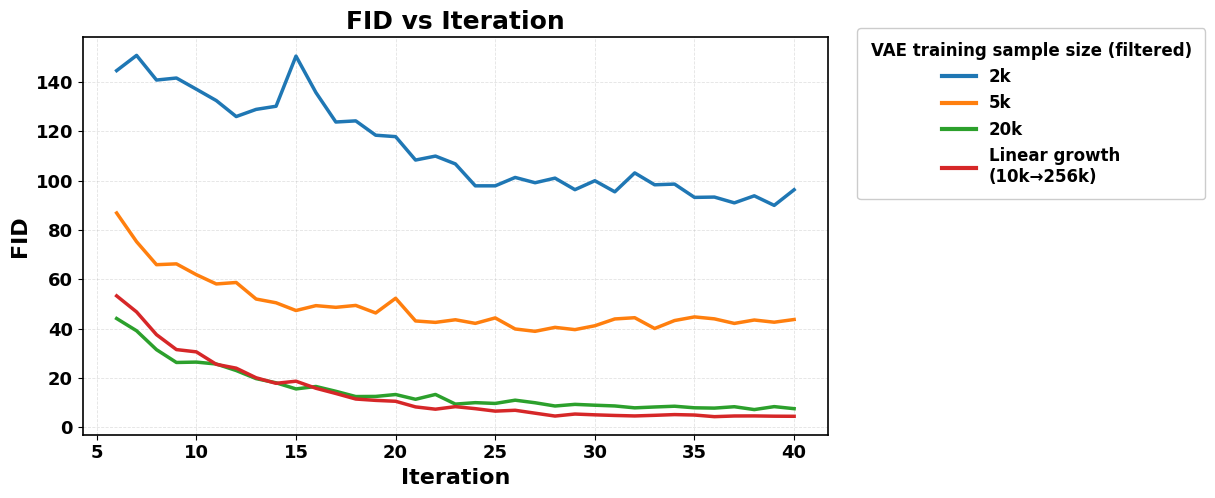

save figure to /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/new_fid_v2_filtered_after5.pdf


In [21]:
def plot_filtered_after_5(metric: str, ylabel: str, savepath: str = None):
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    plt.subplots_adjust(right=0.80)

    # 只保留 filtered & round > 5
    df_sub = df_all[(df_all["filtered"] == True) & (df_all["round"] > 5)].copy()
    unique_sizes = df_sub["size"].unique()

    # 颜色循环
    ax.set_prop_cycle(
        cycler(color=[size_to_color[s] for s in size_order if s in unique_sizes])
    )

    # 画线：只画实线（filtered）
    for s in size_order:
        if s not in unique_sizes:
            continue
        sub = df_sub[df_sub["size"] == s].sort_values("round")
        if len(sub):
            ax.plot(sub["round"], sub[metric], "-", lw=2.5, color=size_to_color[s])

    ax.set_xlabel("Iteration")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs Iteration")
    ax.grid(True, axis="both")

    # 只保留左/下边框即可，也可以像原图那样四边都开
    for sp in ["left", "bottom", "top", "right"]:
        ax.spines[sp].set_visible(True)
        ax.spines[sp].set_linewidth(1.2)

    # 右侧 legend：只有 sample size（不用再区分线型了）
    size_handles = []
    for s in size_order:
        if s in unique_sizes:
            if isinstance(s, int):
                label = f"{s // 1000}k"
            elif s == "linear":
                label = "Linear growth\n(10k→256k)"
            else:
                label = str(s)
            size_handles.append(
                Line2D([0], [0], color=size_to_color[s], lw=3, label=label)
            )

    legend_sizes = fig.legend(
        handles=size_handles,
        title="VAE training sample size (filtered)",
        loc="center left",
        bbox_to_anchor=(1, 0.76),
        frameon=True,
        fancybox=True,
        borderpad=0.8,
        framealpha=1.0,
        title_fontsize=12,
        fontsize=12,
        bbox_transform=fig.transFigure,
    )
    legend_sizes.set_zorder(5)

    # 如果想纵轴再 zoom 一点可以开这一行，比如只看 0–250：
    # ax.set_ylim(0, 250)

    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=600, bbox_inches="tight", transparent=True)
    plt.show()


# 调用：
plot_filtered_after_5(
    metric="mnist_fid_v2_fixed",
    ylabel="FID",
    savepath="/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/new_fid_v2_filtered_after5.pdf",
)
print(f"save figure to /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/new_fid_v2_filtered_after5.pdf")


Verifier sizes: [500, 1000, 5000, 10000, 20000, 40000, 60000]


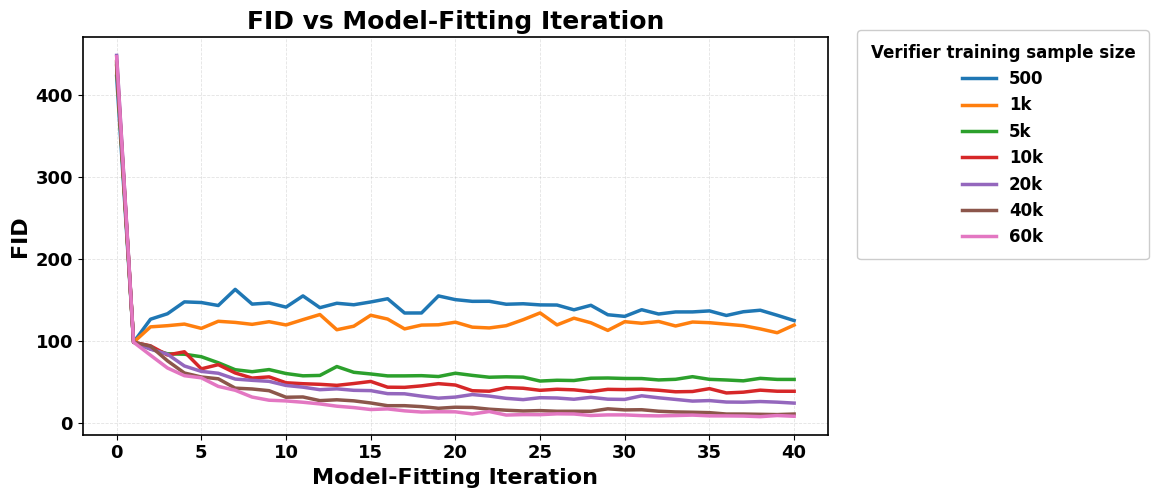

[SAVE] Figure saved to /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fid_vs_iter_dic_verifier.pdf


In [23]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler
from matplotlib.lines import Line2D

# ========= 0. 全局设置 =========
ROOT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/"

# 把某些目录手动映射到 verifier_size
OVERRIDE_VERIFIER_SIZE = {
    "fixed_size_20000": 60000,   # 相当于 dic_60000
}

mpl.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.35,
})

# ========= 1. 读入 dic_* / fixed_size_20000 的 fid_results.csv =========
rows = []

for entry in os.scandir(ROOT):
    if not entry.is_dir():
        continue

    dirname = entry.name

    # 只要 dic_* 或 fixed_size_20000
    if not (dirname.startswith("dic_") or dirname in OVERRIDE_VERIFIER_SIZE):
        continue

    # 解析 verifier_size
    if dirname in OVERRIDE_VERIFIER_SIZE:
        verifier_size = OVERRIDE_VERIFIER_SIZE[dirname]
    else:
        m = re.match(r"dic_(\d+)$", dirname)
        if not m:
            continue
        verifier_size = int(m.group(1))

    csv_path = os.path.join(entry.path, "fid_results.csv")
    if not os.path.exists(csv_path):
        print(f"[WARN] missing fid_results.csv in {entry.path}")
        continue

    df = pd.read_csv(csv_path)
    if "round" not in df.columns or "mnist_fid_v2_fixed" not in df.columns:
        print(f"[WARN] {csv_path} missing 'round' or 'mnist_fid_v2_fixed'")
        continue

    # 把每一行拉平到统一表
    for _, r in df.iterrows():
        rows.append({
            "verifier_size": verifier_size,
            "round": int(r["round"]),
            "mnist_fid_v2_fixed": float(r["mnist_fid_v2_fixed"]),
        })

df_all = pd.DataFrame(rows)
df_all = df_all.dropna(subset=["mnist_fid_v2_fixed"]).copy()

# 查看一下
print("Verifier sizes:", sorted(df_all["verifier_size"].unique()))

# ========= 2. 配色等辅助 =========
verifier_order = sorted(df_all["verifier_size"].unique())

default_colors = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
if len(default_colors) < len(verifier_order):
    import itertools
    default_colors = list(itertools.islice(itertools.cycle(default_colors), len(verifier_order)))
verifier_to_color = {s: default_colors[i] for i, s in enumerate(verifier_order)}

def _fmt_size_label(n):
    return f"{n//1000}k" if n >= 1000 else f"{n}"

# ========= 3. 画图函数：只画 filtered（字典 retraining） =========
def plot_metric_pretty_filtered(metric: str, ylabel: str,
                                savepath: str = None, first_round: int = 1):
    if metric not in df_all.columns:
        print(f"[WARN] metric '{metric}' not in dataframe.")
        return

    # 所有 verifier_size 在 round==first_round 时的平均值
    mask_r1 = (df_all["round"] == first_round)
    r1_mean = df_all.loc[mask_r1, metric].mean() if mask_r1.any() else None
    if r1_mean is None:
        print(f"[WARN] no rows with round == {first_round} for metric '{metric}'.")

    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    plt.subplots_adjust(right=0.80)

    # 固定颜色循环
    ax.set_prop_cycle(cycler(color=[verifier_to_color[s] for s in verifier_order]))

    # 逐个 verifier_size 画线
    for s in verifier_order:
        sub = df_all[df_all["verifier_size"] == s].sort_values("round").copy()
        if len(sub) == 0:
            continue

        # 可选: 把第一轮统一成平均值，方便比较起点
        if r1_mean is not None:
            idx = (sub["round"] == first_round)
            if idx.any():
                sub.loc[idx, metric] = r1_mean

        ax.plot(sub["round"], sub[metric], "-", lw=2.5, color=verifier_to_color[s])

    # x,y轴+标题
    ax.set_xlabel("Model-Fitting Iteration", fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(f"{ylabel} vs Model-Fitting Iteration", fontweight="bold")
    ax.grid(True, axis="both")

    # 边框
    for sp in ["left", "bottom", "top", "right"]:
        ax.spines[sp].set_visible(True)
        ax.spines[sp].set_linewidth(1.2)

    # ---------- Legend：verifier size ----------
    size_handles = [
        Line2D([0], [0], color=verifier_to_color[s], lw=2.5, label=_fmt_size_label(s))
        for s in verifier_order
    ]

    legend_sizes = fig.legend(
        handles=size_handles,
        title="Verifier training sample size",
        loc="center left",
        bbox_to_anchor=(1, 0.7),
        frameon=True, fancybox=True, borderpad=0.8, framealpha=1.0,
        title_fontsize=12, fontsize=12,
        bbox_transform=fig.transFigure,
    )
    legend_sizes.set_zorder(5)
    legend_sizes.get_title().set_fontweight("bold")
    for text in legend_sizes.get_texts():
        text.set_fontweight("bold")

    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=600, bbox_inches="tight", transparent=True)
    plt.show()

# ========= 4. 调用：画 FID 曲线 =========
plot_metric_pretty_filtered(
    metric="mnist_fid_v2_fixed",
    ylabel="FID",
    savepath=os.path.join(ROOT, "fid_vs_iter_dic_verifier.pdf"),
    first_round=1,   # 如果不要统一第一轮，可以改成其它 round 或者在函数里去掉那段逻辑
)
print(f"[SAVE] Figure saved to {os.path.join(ROOT, 'fid_vs_iter_dic_verifier.pdf')}")

# different initial sample size

/tmp/ipykernel_1103647/3613315807.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  palette = mpl.cm.get_cmap("tab10")


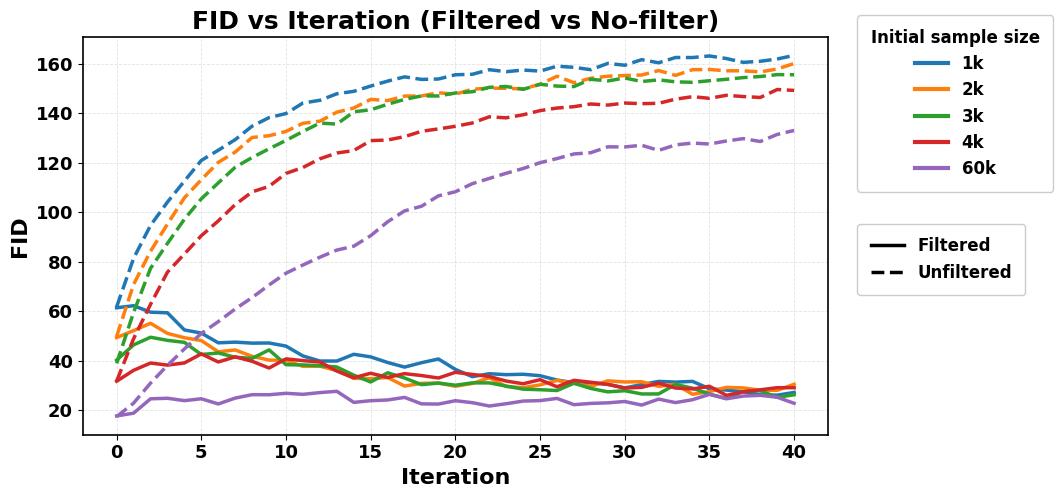

[SAVE] Figure saved to /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fid_filtered_vs_nofilter.pdf


In [12]:
import os
import re
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from cycler import cycler
from matplotlib.lines import Line2D

# ================= rcParams ================
mpl.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.35,
})

# ================= Paths ================
ROOT_FILT = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/larger_initial_sample_size"
ROOT_NOF  = "/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/schedule_size_linear_no_filter"

init_sizes = [1000, 2000, 3000, 4000, 60000]

# ================= Helper ================
def parse_round(model_name: str) -> int:
    if "real" in model_name:
        return 0
    m = re.search(r"_r(\d+)", model_name)
    return int(m.group(1)) if m else -1


records = []

# ================= Load Filtered ====================
for s in init_sizes:
    csv_path = os.path.join(
        ROOT_FILT,
        f"init_{s}",
        "results_saved_more",
        f"results_table_init{s}_40rounds.csv"
    )
    df = pd.read_csv(csv_path)
    df["round"] = df["model_name"].apply(parse_round)
    df = df[df["round"] >= 0]

    for _, row in df.iterrows():
        records.append({
            "init_size": s,
            "filtered": True,
            "round": int(row["round"]),
            "fid": float(row["fid"]),
        })

# ================= Load No-Filter ====================
for s in init_sizes:
    base_dir = os.path.join(
        ROOT_NOF,
        f"init_{s}",
        "results_saved_no_filter_more",
    )
    # 两种可能的文件名
    cand1 = os.path.join(base_dir, f"results_table_init{s}_40rounds.csv")
    cand2 = os.path.join(base_dir, f"results_table_{s}_40rounds.csv")

    if os.path.exists(cand1):
        csv_path = cand1
    elif os.path.exists(cand2):
        csv_path = cand2
    else:
        print(f"[WARN] no csv found for init_{s} in {base_dir}")
        continue

    df = pd.read_csv(csv_path)
    df["round"] = df["model_name"].apply(parse_round)
    df = df[df["round"] >= 0]

    for _, row in df.iterrows():
        records.append({
            "init_size": s,
            "filtered": False,
            "round": int(row["round"]),
            "fid": float(row["fid"]),
        })

df_all = pd.DataFrame.from_records(records)

# ================== Color Map ======================
palette = mpl.cm.get_cmap("tab10")
size_to_color = {init_sizes[i]: palette(i) for i in range(len(init_sizes))}

# ================== Plot =====================
def plot_fid(df_all, savepath=None):
    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    plt.subplots_adjust(right=0.80)

    # Colors follow initial size
    ax.set_prop_cycle(cycler(color=[size_to_color[s] for s in init_sizes]))

    for s in init_sizes:
        df_s = df_all[df_all["init_size"] == s]

        df_f = df_s[df_s["filtered"] == True].sort_values("round")
        df_nf = df_s[df_s["filtered"] == False].sort_values("round")

        if len(df_f):
            ax.plot(df_f["round"], df_f["fid"],
                    "-", lw=2.5, label=f"{s} filtered",
                    color=size_to_color[s])
        if len(df_nf):
            ax.plot(df_nf["round"], df_nf["fid"],
                    "--", lw=2.5, label=f"{s} no-filter",
                    color=size_to_color[s])

    ax.set_xlabel("Iteration")
    ax.set_ylabel("FID")
    ax.set_title("FID vs Iteration (Filtered vs No-filter)")
    ax.grid(True)

    # Border
    for sp in ["left", "bottom", "top", "right"]:
        ax.spines[sp].set_visible(True)
        ax.spines[sp].set_linewidth(1.2)

     # ================= Legend A: initial sample size（右上） =================
    size_handles = []
    for s in init_sizes:
        label = f"{s//1000}k" if s >= 1000 else str(s)
        size_handles.append(
            Line2D(
                [0], [0],
                color=size_to_color[s],
                lw=3,
                linestyle="-",   # 颜色 legend 统一用实线
                label=label
            )
        )

    legend_sizes = fig.legend(
        handles=size_handles,
        title="Initial sample size",
        loc="center left",
        bbox_to_anchor=(1.00, 0.78),     # ← 调整这个位置
        frameon=True,
        fancybox=True,
        borderpad=0.8,
        framealpha=1.0,
        title_fontsize=12,
        fontsize=12,
        bbox_transform=fig.transFigure
    )
    legend_sizes.set_zorder(5)

    # ================= Legend B: filtered / unfiltered（右中） =================
    ls_handles = [
        Line2D([0], [0], color="black", lw=2.5, linestyle="-",  label="Filtered"),
        Line2D([0], [0], color="black", lw=2.5, linestyle="--", label="Unfiltered"),
    ]

    legend_ls = fig.legend(
        handles=ls_handles,
        title="",
        loc="center left",
        bbox_to_anchor=(1.00, 0.48),     # ← legend B 稍微往下放
        frameon=True,
        fancybox=True,
        borderpad=0.8,
        framealpha=1.0,
        title_fontsize=12,
        fontsize=12,
        bbox_transform=fig.transFigure
    )
    legend_ls.set_zorder(5)


    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=600, bbox_inches="tight", transparent=True)
    plt.show()


plot_fid(
    df_all,
    savepath="/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fid_filtered_vs_nofilter.pdf"
)
print(f"[SAVE] Figure saved to /home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/conv_cvae/fid_filtered_vs_nofilter.pdf")
